<h2><center> 🎥 🍿 Elyssa Project – The Odyssey of Cinematic Intelligence 🥤🎬 </center></h2>

<h4><center> From Raw & Fragmented Data to Alluring Insights: Data Architecture, Predictive Analytics, and Machine Learning  </center></h4>

<p><b>Dataset Author:</b> IMDb Developer. (2026). </p>

<p><b>Official Sources:</b>
<a href="https://datasets.imdbws.com/" target="_blank">IMDb Non-Commercial Datasets</a>,</p>
<p><b> Launch Date:</b> June 24th - Present </p>

<p><b>Successors</b>:</p>
<ul>
        <li> Dominique, A. (2024). <i> Analyzing Genre Influence on IMDb Ratings for Film and TV </i>. Github. <a href="https://github.com/dominiqueakinyemi/IMDb_Genre_Analysis" target="_blank">[Repository]</a></li>
        <li> Fredo, A. (2025). <i> Movie Performance Prediction - Ratings & Casting </i>. Github. <a href="https://github.com/fredo123aaa/Movie-Performance-Prediction-Based-on-Ratings-and-Casting" target="_blank">[Repository]</a></li>
        <li> Himanshu, D. (2026). <i> IMDB Top 250 Movies – Data Analytics Project </i>. Github. <a href="https://github.com/himanshudeol/IMDB_Top_Charts_Project" target="_blank">[Repository]</a></li>
        <li> Mirza, S. (2025). <i> IMDb Movie Data Analysis </i>. Github. <a href="https://github.com/saifalibaig/IMDB-Movie-Data-Analysis-Using-Python" target="_blank">[Repository]</a></li>
        <li> Maha, A. (2023). <i> Data Science Mini-Project </i>. Github. <a href = "https://github.com/maha-rw/Data-Science-mini-project"> [Repository]</a></li>
        <li> Aliza, I. (2024). <i> Movie Review Clustering Using KMeans </i>. Github. <a href = "https://github.com/Aliza-03/IMDB_Movie_Review_KMeansClustering"> [Repository]</a></li>
        <li> Gioconda, P. (2025). <i> IMDB Movie Analysis </i>. Github. <a href = "https://github.com/giocondaprada91/IMDB_Movie_Analysis"> [Repository]</a></li>
    </ul>

<p><b>EDA Performer:</b> Duke (formerly known as Cresht) </p>

**Preamble**: The entertainment industry operates as a complex, interconnected network of directors, actors, studios, and thematic elements. Understanding the patterns, trends, and anomalies within this network requires exploratory data analysis that moves beyond mere description toward actionable insight generation. This notebook inherits a theme based investigative framework and implements it into the Gold Layer of IMDb schema, where questions are organized around substantive domains rather than individual queries.

### **Part A - Preliminaries**

### Imports & Initialization ###

In [ ]:
# Database Preliminaries
import duckdb, psycopg2
import pandas as pd
from pathlib import Path
from datetime import datetime
import time, json

# Exploratory Data Analysis
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import pycountry
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from networkx.algorithms import community

import seaborn as sns
import networkx as nx

import logging
logger = logging.getLogger('elyssa.eda')

plot_all = {}

# Paths
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = (NOTEBOOK_DIR.parent / 'marts').resolve()
GOLD_DIR = (DATA_DIR / 'gold').resolve()
MODELS_DIR = (NOTEBOOK_DIR.parent / 'notebooks' / 'models').resolve()
FIGURES_DIR = (NOTEBOOK_DIR.parent / 'figures').resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)


### Database Connection & Gold-Table Registration ###

All EDA modules now inherits the dimensional Gold-Layer - a star-schema composed of:
- **dim_title** - one row per title, containing title attributes, aggregated ratings, genre lists, director/writer names, and series/episode metadata.
- **dim_person** - one row per person, with biographical details, profession lists, and known titles.
- **fact_title_rating** - historical snapshots of ratings and vote counts per title (time variant).
- **fact_title_principal** - principal cast and crew per title (character, ordering, category, job).
- **fact_performance** - credited roles linking titles and persons.
- **fact_episode** - episode level details for TV series (season, episode number, series reference).

_Note: If parquet files are partitioned (multiple files in a a)_

In [ ]:
# Create a persistent DuckDB database (either use ':memory' for temporary or 'imdb_gold.db')
con = duckdb.connect(database='imdb_gold.db')

# List of table names (views) and their corresponding parquet files
tables = {
    'dim_title':            GOLD_DIR / 'dim_title.parquet',
    'dim_person':           GOLD_DIR / 'dim_person.parquet',
    'fact_title_rating':    GOLD_DIR / 'fact_title_rating.parquet',
    'fact_performance':     GOLD_DIR / 'fact_performance.parquet',
    'fact_episode':         GOLD_DIR / 'fact_episode.parquet',
    'fact_title_principal': GOLD_DIR / 'fact_title_principal.parquet',
}

# Create views for each table
for view_name, file_path in tables.items():
    if file_path.exists():
        con.execute(f"""
            CREATE OR REPLACE VIEW {view_name} AS
            SELECT * FROM read_parquet('{file_path.as_posix()}')
        """)
        logger.info(f'✓ {view_name} registered')
    else:
        logger.info(f'✗ Missing file: {file_path}')

### Quick Sanity Check (Row Counts) ###

In [8]:
for view_name in tables:
    try:
        count = con.execute(f"SELECT COUNT(*) FROM {view_name}").fetchone()[0]
        logger.info(f"{view_name:25s} → {count:>10,} rows")
    except Exception as e:
        logger.info(f"{view_name:25s} → error: {e}")

### Database Queries To Dataframe ###

In [9]:
# Use this across the notebook to run analytical SQL and bring aggregated results into a pd.DataFrame for plotting
def query_to_df(sql: str, params = None) -> pd.DataFrame:
    """
    Execute SQL against the DuckDB connection and return a pandas DataFrame.
    Only use for aggregated / filtered results to keep memory usage low.
    """
    if params:
        return con.execute(sql, params).df()
    else:
        return con.execute(sql).df()

### Query Example ###

In [10]:
# Count titles per genre (genre_list is a VARCHAR list column)
df_genre_count = query_to_df("""
    SELECT
        trim(genre) AS genre,
        COUNT(*) AS cnt
    FROM dim_title,
    UNNEST(string_split(genre_list, ',')) AS t(genre)
    WHERE genre_list IS NOT NULL
    GROUP BY trim(genre)
    ORDER BY cnt DESC;
""")
df_genre_count.head(10)


,genre,cnt
0,Drama,3515373
1,Comedy,2433058
2,Talk-Show,1563207
3,Short,1339360
4,News,1283610
5,Documentary,1203304
6,Romance,1158585
7,Family,907125
8,Reality-TV,708408
9,Animation,631105


In [11]:
con.sql("SELECT * FROM dim_title ORDER BY RANDOM() LIMIT 10").df()

,tconst,title_type,primary_title,original_title,is_adult,start_year,end_year,runtime_minutes,genre_list,director_names,writer_names,average_rating,num_votes,popularity_segment,rating_bucket,parent_tconst,series_title,season_number,episode_number,region_list,language_list,aka_count
0,tt16073522,tvEpisode,DFP Academy: Approving her Transfer Step 2,DFP Academy: Approving her Transfer Step 2,1,2021,<NA>,<NA>,Adult,None,None,NaN,<NA>,unknown,unrated,tt11668838,DFP Productions,None,None,None,None,<NA>
1,tt4800578,tvEpisode,Civil Rights and Wrongs,Civil Rights and Wrongs,0,2015,<NA>,<NA>,Reality-TV,None,"Deion Sanders, Tracey E. Edmonds",NaN,<NA>,unknown,unrated,tt3527950,Deion's Family Playbook,3,6,None,None,<NA>
2,tt41389866,tvEpisode,Episode dated 12 March 1991,Episode dated 12 March 1991,0,1991,<NA>,<NA>,"News,Talk-Show",None,None,NaN,<NA>,unknown,unrated,tt0154053,ABC News Nightline,None,None,"IN, DE, FR, IT, JP, PT, ES","fr, ja, de, pt, es, hi, it",7
3,tt15299064,tvEpisode,Episode #1.815,Episode #1.815,0,2004,<NA>,<NA>,Drama,None,Ekta Kapoor,NaN,<NA>,unknown,unrated,tt1341970,Kahaani Ghar Ghar Kii,1,815,"PT, ES, IN, DE, FR, IT, JP","es, it, ja, hi, pt, fr, de",7
4,tt33569539,tvEpisode,Heels,Heels,0,2024,<NA>,<NA>,Documentary,None,None,NaN,<NA>,unknown,unrated,tt33568271,GoGo Battles Mania!,1,3,None,None,<NA>
5,tt22000174,tvEpisode,Episode #1.774,Episode #1.774,0,2022,<NA>,<NA>,News,None,None,NaN,<NA>,unknown,unrated,tt21998536,Shuukan Mikumiku rankingu,1,774,"PT, ES, JP, IT, FR, IN, DE","ja, hi, it, es, fr, de, pt",7
6,tt7461322,tvEpisode,Episode #2.185,Episode #2.185,0,2017,<NA>,<NA>,Sport,None,None,NaN,<NA>,unknown,unrated,tt5709400,Speak,2,185,"PT, ES, IN, DE, IT, FR, JP","es, it, ja, hi, fr, pt, de",7
7,tt2828528,short,Autsch,Autsch,0,2008,<NA>,<NA>,Short,Lillian Rosa,None,NaN,<NA>,unknown,unrated,None,None,None,None,DE,None,1
8,tt27803983,tvEpisode,Episode #6.65,Episode #6.65,0,2022,<NA>,180,Reality-TV,"Alessio Pollacci, Marco Fuortes",John de Mol,NaN,<NA>,unknown,unrated,tt6078678,Grande Fratello VIP,6,65,"ES, FR, JP, IT, PT, IN, DE","hi, ja, de, fr, pt, es, it",7
9,tt5183470,tvEpisode,Episode dated 10 February 2010,Episode dated 10 February 2010,0,2010,<NA>,<NA>,None,None,Alicia Santolaya,NaN,<NA>,unknown,unrated,tt0447759,Gente,None,None,"FR, ES, JP, DE, IN, PT, IT","it, de, ja, hi, es, pt, fr",7


### **Part B - Gold Marts Benchmark**

### B.1 — Bronze Registration (7 tables, two-strategy) ###

In [ ]:
BRONZE_TABLES = [
    'title.basics', 'title.akas', 'title.crew',
    'title.episode', 'title.principals', 'title.ratings', 'name.basics'
]

BRONZE_DIR = DATA_DIR / "bronze"

# Track which strategy succeeded per table
bronze_strategy = {}

for table in BRONZE_TABLES:
    alias = table.replace(".", "_")
    path = BRONZE_DIR / f"{table}.parquet"
    if path.exists():
        con.execute(f"""
            CREATE OR REPLACE VIEW bronze_{alias} AS
            SELECT * FROM read_parquet('{path.as_posix()}')
        """)
        bronze_strategy[alias] = "Strategy 1 (local cache)"
        logger.info(f"✓ bronze_{alias} (Strategy 1: local cache)")
    else:
        # Strategy 2: S3 fallback via httpfs
        try:
            con.execute("INSTALL httpfs; LOAD httpfs;")
        except Exception:
            pass
        con.execute("SET s3_endpoint = 'rustfs:9000'")
        con.execute("SET s3_access_key_id = 'elyssa'")
        con.execute("SET s3_secret_access_key = 'elyssa_s3_2026'")
        con.execute("SET s3_region = 'us-east-1'")
        con.execute("SET s3_url_style = 'path'")
        con.execute("SET s3_use_ssl = false")
        s3_path = f"s3://imdb-source/{table}.tsv.gz"
        try:
            con.execute(f"""
                CREATE OR REPLACE VIEW bronze_{alias} AS
                SELECT * FROM read_csv('{s3_path}',
                    delim='\t', header=True, all_varchar=True,
                    nullstr='\\N', quote='', escape='')
            """)
            bronze_strategy[alias] = "Strategy 2 (S3)"
            logger.info(f"✓ bronze_{alias} (Strategy 2: S3)")
        except Exception as e:
            bronze_strategy[alias] = None
            logger.warning(f"✗ bronze_{alias}: {e}")


### B.2 — Silver Registration (14 tables, two-strategy) ###

In [ ]:
SILVER_TABLES = [
    'title_basics', 'title_akas', 'title_crew', 'title_episode',
    'title_principal', 'title_rating', 'name_basics',
    'title_genre', 'title_director', 'title_writer',
    'title_akas_type', 'title_akas_attribute', 'title_principal_char',
    'name_profession', 'name_known_for_title'
]

SILVER_DIR = DATA_DIR / "silver"
silver_counts = {}

# Strategy 1: Local Silver Parquet cache
for table in SILVER_TABLES:
    path = SILVER_DIR / f"{table}.parquet"
    if path.exists():
        cnt = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path.as_posix()}')").fetchone()[0]
        silver_counts[table] = cnt
        logger.info(f"✓ silver_{table}: {cnt:,} rows (Strategy 1: local cache)")
    else:
        silver_counts[table] = None

# Strategy 2: PostgreSQL fallback (row counts only)
if not any(v is not None for v in silver_counts.values()):
    try:
        pg = psycopg2.connect(
            host="postgres", port=5432,
            user="elyssa", password="elyssa_pg_2026",
            dbname="elyssa_warehouse"
        )
        logger.info("Reading Silver from PostgreSQL...")
        for table in SILVER_TABLES:
            try:
                cur = pg.cursor()
                cur.execute(f"SELECT COUNT(*) FROM silver.{table}")
                cnt = cur.fetchone()[0]
                silver_counts[table] = cnt
                logger.info(f"  silver.{table}: {cnt:,} rows")
            except Exception as e:
                silver_counts[table] = None
                logger.warning(f"  silver.{table}: {e}")
        pg.close()
    except Exception as e:
        logger.warning(f"PostgreSQL connection failed: {e}")
else:
    logger.info("Silver cache hit — skipping PostgreSQL query")


### B.3 — Gold Registration

Gold marts are already registered in **Part A** from `data-science/marts/gold/`.
No fallback needed — Gold lives on the host bind mount.


In [ ]:
GOLD_TABLES = [
    'dim_title', 'dim_person', 'fact_title_rating',
    'fact_title_principal', 'fact_performance', 'fact_episode'
]

gold_counts = {}
for table in GOLD_TABLES:
    path = GOLD_DIR / f"{table}.parquet"
    if path.exists():
        cnt = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path.as_posix()}')").fetchone()[0]
        gold_counts[table] = cnt
    else:
        gold_counts[table] = None


### B.4 — Row Count Reconciliation ###

In [ ]:
# List of dicts
bench = []

# Helper to add a result
def add_check(category, description, value=None, status='OK', note=''):
    bench.append({
        'Category': category,
        'Check': description,
        'Value': value,
        'Status': status,
        'Note': note
    })

# Row counts for all tables

# Bronze
bronze_row_counts = {}
for table in BRONZE_TABLES:
    alias = table.replace(".", "_")
    try:
        bronze_row_counts[alias] = con.execute(f"SELECT COUNT(*) FROM bronze_{alias}").fetchone()[0]
    except Exception:
        bronze_row_counts[alias] = None
    add_check('Row Counts', f'Bronze: {alias}', bronze_row_counts.get(alias), 'OK' if bronze_row_counts.get(alias) is not None else 'WARN')

# Silver
for table in SILVER_TABLES:
    cnt = silver_counts.get(table)
    add_check('Row Counts', f'Silver: {table}', cnt, 'OK' if cnt is not None else 'WARN')

# Gold
for table in GOLD_TABLES:
    cnt = gold_counts.get(table)
    add_check('Row Counts', f'Gold: {table}', cnt, 'OK' if cnt is not None else 'WARN')

# Cross-layer ratios (Bronze→Silver→Gold)
layer_available = {
    'Bronze': any(v is not None for v in bronze_row_counts.values()),
    'Silver': any(v is not None for v in silver_counts.values()),
    'Gold': any(v is not None for v in gold_counts.values()),
}

for layer, available in layer_available.items():
    if not available:
        add_check('Row Counts', f'{layer} layer unavailable', None, 'WARN')

# Specific cross-layer checks
mapping = [
    ('title_basics', 'title_basics', 'dim_title'),
    ('name_basics', 'name_basics', 'dim_person'),
    ('title_ratings', 'title_rating', 'fact_title_rating'),
    ('title_principals', 'title_principal', 'fact_title_principal'),
    ('title_episode', 'title_episode', 'fact_episode'),
]
for b_name, s_name, g_name in mapping:
    b_alias = b_name.replace(".", "_")
    b = bronze_row_counts.get(b_alias)
    s = silver_counts.get(s_name)
    g = gold_counts.get(g_name)
    if b and s:
        ratio = s / b
        status = 'OK' if 0.95 <= ratio <= 1.05 else 'WARN'
        add_check('Cross-Layer Ratios', f'Silver/Bronze: {b_alias}/{s_name}', f'{ratio:.2%}', status)
    if b and g:
        ratio = g / b
        status = 'OK' if 0.95 <= ratio <= 1.05 else 'WARN'
        add_check('Cross-Layer Ratios', f'Gold/Bronze: {b_alias}/{g_name}', f'{ratio:.2%}', status)
    if s and g:
        ratio = g / s
        status = 'OK' if 0.95 <= ratio <= 1.05 else 'WARN'
        add_check('Cross-Layer Ratios', f'Gold/Silver: {s_name}/{g_name}', f'{ratio:.2%}', status)


### B.5 — ETL Correctness (Enhanced) ###

In [ ]:
# ========================= ETL CORRECTNESS =========================

# Row counts (Bronze vs Gold) — original checks
for bronze_name, gold_name, note in [
    ('title_basics',     'dim_title',            ''),
    ('name_basics',      'dim_person',           ''),
    ('title_principals', 'fact_title_principal', ''),
    ('title_episode',    'fact_episode',         ''),
]:
    try:
        b_count = con.execute(f"SELECT count(*) FROM bronze_{bronze_name}").fetchone()[0]
    except Exception as e:
        logger.warning(f"Query failed: {e}")
        b_count = None
    try:
        g_count = con.execute(f"SELECT count(*) FROM {gold_name}").fetchone()[0]
    except Exception as e:
        logger.warning(f"Query failed: {e}")
        g_count = None
    match = 'OK' if (b_count is not None and g_count is not None and b_count == g_count) else 'WARN'
    add_check('ETL Correctness', f'Row count: bronze_{bronze_name} vs {gold_name}',
              f'Bronze: {b_count}, Gold: {g_count}', match, note)

# Special: title_crew rows vs distinct titles with director/writer in fact_performance
try:
    b_crew = con.execute("SELECT count(*) FROM bronze_title_crew").fetchone()[0]
except Exception as e:
    logger.warning(f"Query failed: {e}")
    b_crew = None
try:
    g_crew_titles = con.execute("SELECT count(DISTINCT tconst) FROM fact_performance WHERE category IN ('director','writer')").fetchone()[0]
except Exception as e:
    logger.warning(f"Query failed: {e}")
    g_crew_titles = None
match = 'OK' if (b_crew is not None and g_crew_titles is not None and b_crew == g_crew_titles) else 'WARN'
add_check('ETL Correctness', 'title_crew (Bronze) vs distinct titles with director/writer in fact_performance',
          f'Bronze: {b_crew}, Gold distinct titles: {g_crew_titles}', match,
          'One row per tconst in Bronze; Gold splits into multiple rows per person.')

# Distinct keys
try:
    b_tconst = con.execute("SELECT count(DISTINCT tconst) FROM bronze_title_basics").fetchone()[0]
    g_tconst = con.execute("SELECT count(DISTINCT tconst) FROM dim_title").fetchone()[0]
    match = 'OK' if b_tconst == g_tconst else 'WARN'
    add_check('ETL Correctness', 'Distinct tconst: bronze_title_basics vs dim_title',
              f'Bronze: {b_tconst}, Gold: {g_tconst}', match)
except Exception as e:
    add_check('ETL Correctness', 'Distinct tconst: bronze vs dim_title', 'Error', 'FAIL', str(e))

try:
    b_nconst = con.execute("SELECT count(DISTINCT nconst) FROM bronze_name_basics").fetchone()[0]
    g_nconst = con.execute("SELECT count(DISTINCT nconst) FROM dim_person").fetchone()[0]
    match = 'OK' if b_nconst == g_nconst else 'WARN'
    add_check('ETL Correctness', 'Distinct nconst: bronze_name_basics vs dim_person',
              f'Bronze: {b_nconst}, Gold: {g_nconst}', match)
except Exception as e:
    add_check('ETL Correctness', 'Distinct nconst: bronze vs dim_person', 'Error', 'FAIL', str(e))

# Rating consistency (Bronze ratings vs dim_title)
try:
    mismatch = con.execute("""
        SELECT count(*) FROM (
            SELECT b.tconst, CAST(b.averageRating AS FLOAT) AS br, d.average_rating AS gr
            FROM bronze_title_ratings b
            JOIN dim_title d ON b.tconst = d.tconst
            WHERE b.averageRating NOT LIKE '\\N'
              AND d.average_rating IS NOT NULL
              AND abs(CAST(b.averageRating AS FLOAT) - d.average_rating) > 0.01
        ) t
    """).fetchone()[0]
    total = con.execute("""
        SELECT count(*) FROM bronze_title_ratings b
        JOIN dim_title d ON b.tconst = d.tconst
        WHERE b.averageRating NOT LIKE '\\N' AND d.average_rating IS NOT NULL
    """).fetchone()[0]
    match = 'OK' if mismatch == 0 else 'WARN'
    add_check('ETL Correctness', 'Rating mismatch > 0.01 (bronze vs dim_title)',
              f'{mismatch} of {total}', match)
except Exception as e:
    add_check('ETL Correctness', 'Rating mismatch check', 'Error', 'FAIL', str(e))

# Completeness: Gold titles not present in Bronze (if any)
try:
    b_tconst_set = con.execute("SELECT count(DISTINCT tconst) FROM bronze_title_basics").fetchone()[0]
    g_tconst_set = con.execute("SELECT count(DISTINCT tconst) FROM dim_title").fetchone()[0]
    if b_tconst_set != g_tconst_set:
        missing = con.execute("""
            SELECT count(*) FROM dim_title d
            LEFT JOIN bronze_title_basics b ON d.tconst = b.tconst
            WHERE b.tconst IS NULL
        """).fetchone()[0]
        add_check('ETL Correctness', 'dim_title tconst missing from bronze_title_basics',
                  missing, 'WARN' if missing > 0 else 'OK')
    else:
        add_check('ETL Correctness', 'dim_title tconst missing from bronze_title_basics',
                  '0', 'OK', 'All Gold titles present in Bronze.')
except Exception as e:
    add_check('ETL Correctness', 'Completeness check failed', 'Error', 'FAIL', str(e))

# Silver-aware comparisons (when Silver is available)
if layer_available.get('Silver'):
    for s_name, g_name in [
        ('title_basics', 'dim_title'),
        ('name_basics', 'dim_person'),
        ('title_rating', 'fact_title_rating'),
        ('title_principal', 'fact_title_principal'),
        ('title_episode', 'fact_episode'),
    ]:
        s_cnt = silver_counts.get(s_name)
        g_cnt = gold_counts.get(g_name)
        if s_cnt is not None and g_cnt is not None:
            ratio = g_cnt / s_cnt
            status = 'OK' if 0.95 <= ratio <= 1.05 else 'WARN'
            add_check('ETL Correctness', f'Gold/Silver ratio: {s_name} vs {g_name}',
                      f'{ratio:.2%}', status)


### B.6 — Intrinsic Quality (Enhanced) ###

In [ ]:
# ========================= INTRINSIC GOLD QUALITY =========================

# Uniqueness of primary keys
pk_checks = [
    ('dim_title', 'tconst'),
    ('dim_person', 'nconst'),
    ('fact_title_principal', 'tconst, ordering'),
    ('fact_title_rating', 'title_key, snapshot_date'),
    ('fact_episode', 'series_key, season_number, episode_number'),
    ('fact_performance', 'tconst, nconst, category'),
]
for table, keys in pk_checks:
    sql = f"SELECT count(*) - count(DISTINCT {keys}) FROM {table}"
    try:
        dupes = con.execute(sql).fetchone()[0]
        add_check('Intrinsic Quality', f'Duplicate potential PK ({keys}) in {table}',
                  dupes, 'OK' if dupes == 0 else 'FAIL',
                  'Count of rows minus distinct key combinations; 0 means unique.')
    except Exception as e:
        add_check('Intrinsic Quality', f'PK uniqueness check on {table}', 'Error', 'FAIL', str(e))

# Validity: column constraints
bad_tconst = con.execute("SELECT count(*) FROM dim_title WHERE tconst NOT LIKE 'tt%' OR NOT regexp_matches(tconst, '^tt[0-9]+$')").fetchone()[0]
add_check('Intrinsic Quality', 'Invalid tconst format in dim_title', bad_tconst, 'OK' if bad_tconst==0 else 'FAIL')

bad_nconst = con.execute("SELECT count(*) FROM dim_person WHERE nconst NOT LIKE 'nm%' OR NOT regexp_matches(nconst, '^nm[0-9]+$')").fetchone()[0]
add_check('Intrinsic Quality', 'Invalid nconst format in dim_person', bad_nconst, 'OK' if bad_nconst==0 else 'FAIL')

bad_adult = con.execute("SELECT count(*) FROM dim_title WHERE CAST(is_adult AS INTEGER) NOT IN (0,1)").fetchone()[0]
add_check('Intrinsic Quality', 'is_adult not in (0,1)', bad_adult, 'OK' if bad_adult==0 else 'FAIL')

bad_runtime = con.execute("SELECT count(*) FROM dim_title WHERE CAST(runtime_minutes AS INTEGER) <= 0 AND runtime_minutes IS NOT NULL").fetchone()[0]
add_check('Intrinsic Quality', 'Negative/zero runtime_minutes', bad_runtime, 'OK' if bad_runtime==0 else 'FAIL')

bad_rating = con.execute("SELECT count(*) FROM dim_title WHERE average_rating IS NOT NULL AND (average_rating < 1.0 OR average_rating > 10.0)").fetchone()[0]
add_check('Intrinsic Quality', 'Rating out of bounds [1,10]', bad_rating, 'OK' if bad_rating==0 else 'FAIL')

neg_season = con.execute("SELECT count(*) FROM fact_episode WHERE CAST(season_number AS INTEGER) < 0").fetchone()[0]
neg_episode = con.execute("SELECT count(*) FROM fact_episode WHERE CAST(episode_number AS INTEGER) < 0").fetchone()[0]
add_check('Intrinsic Quality', 'Negative season/episode numbers', f'season: {neg_season}, ep: {neg_episode}',
          'OK' if neg_season==0 and neg_episode==0 else 'FAIL')

allowed_types = ['movie','short','tvEpisode','tvMiniSeries','tvMovie','tvSeries',
                 'tvShort','tvSpecial','video','videoGame']
bad_type = con.execute(f"""
    SELECT count(*) FROM dim_title
    WHERE title_type NOT IN ({",".join(f"'{t}'" for t in allowed_types)})
""").fetchone()[0]
add_check('Intrinsic Quality', 'Unexpected title_type values', bad_type, 'OK' if bad_type==0 else 'FAIL')

bad_temporal = con.execute("""
    SELECT count(*) FROM dim_title
    WHERE end_year IS NOT NULL AND start_year IS NOT NULL AND end_year < start_year
""").fetchone()[0]
add_check('Intrinsic Quality', 'end_year < start_year', bad_temporal, 'OK' if bad_temporal==0 else 'FAIL')

# Part D DQ Anomaly Detection (migrated into B.6)
current_year = datetime.now().year
bad_start_year = con.execute("""
    SELECT count(*) FROM dim_title
    WHERE start_year IS NOT NULL AND (start_year < 1874 OR start_year > 2115)
""").fetchone()[0]
add_check('Intrinsic Quality', 'Out-of-range start_year [1874, 2115]', bad_start_year, 'OK' if bad_start_year==0 else 'FAIL')

bad_runtime_extreme = con.execute("""
    SELECT count(*) FROM dim_title
    WHERE runtime_minutes IS NOT NULL AND runtime_minutes > 1000
""").fetchone()[0]
add_check('Intrinsic Quality', 'Extreme runtime_minutes (> 1000 min)', bad_runtime_extreme, 'OK' if bad_runtime_extreme==0 else 'FAIL')

bad_birth_year = con.execute("""
    SELECT count(*) FROM dim_person
    WHERE birth_year IS NOT NULL AND (birth_year < 1800 OR birth_year > {current_year})
""").fetchone()[0]
add_check('Intrinsic Quality', f'Unrealistic birth_year [1800, {current_year}]', bad_birth_year, 'OK' if bad_birth_year==0 else 'FAIL')

bad_death_before_birth = con.execute("""
    SELECT count(*) FROM dim_person
    WHERE birth_year IS NOT NULL AND death_year IS NOT NULL AND death_year < birth_year
""").fetchone()[0]
add_check('Intrinsic Quality', 'death_year < birth_year', bad_death_before_birth, 'OK' if bad_death_before_birth==0 else 'FAIL')

orphaned_episodes = con.execute("""
    SELECT count(*) FROM fact_episode e
    LEFT JOIN dim_title d ON e.series_key = d.tconst
    WHERE d.tconst IS NULL
""").fetchone()[0]
add_check('Intrinsic Quality', 'Orphaned episode parents (fact_episode.series_key -> dim_title.tconst)',
          orphaned_episodes, 'OK' if orphaned_episodes==0 else 'FAIL')

# Cross-table consistency (sample-based)
try:
    sample = con.execute("""
        SELECT t.tconst, t.director_names,
               (SELECT string_agg(p.primary_name, ', ' ORDER BY f.ordering)
                FROM fact_performance f JOIN dim_person p ON f.nconst = p.nconst
                WHERE f.tconst = t.tconst AND f.category = 'director') AS calc_directors
        FROM dim_title t
        WHERE t.director_names IS NOT NULL AND t.director_names != 'NaN'
        ORDER BY random()
        LIMIT 100
    """).df()
    mismatches = sample.dropna(subset=['calc_directors'])
    mismatches = mismatches[mismatches['director_names'] != mismatches['calc_directors']]
    match_rate = 100.0 * (1 - len(mismatches) / len(sample))
    add_check('Intrinsic Quality', 'Director names consistency (sample 100)',
              f'{match_rate:.1f}% match', 'OK' if match_rate > 90 else 'WARN')
except Exception as e:
    add_check('Intrinsic Quality', 'Director names consistency check', 'Error', 'FAIL', str(e))

try:
    bad_series = con.execute("""
        SELECT count(DISTINCT e.series_key)
        FROM fact_episode e
        LEFT JOIN dim_title d ON e.series_key = d.tconst
        WHERE d.tconst IS NULL OR d.title_type NOT LIKE '%tv%'
    """).fetchone()[0]
    add_check('Intrinsic Quality', 'fact_episode.series_key does not refer to a TV series title',
              bad_series, 'OK' if bad_series==0 else 'FAIL')
except Exception as e:
    add_check('Intrinsic Quality', 'Episode series type check', 'Error', 'FAIL', str(e))


### B.7 — Completeness & Null-Rate Summary ###

In [ ]:
# MANIFEST.json drift check (> 1% -> WARN)
manifest_path = GOLD_DIR / "_MANIFEST.json"
if manifest_path.exists():
    with open(manifest_path) as f:
        manifest = json.load(f)
    declared_counts = manifest.get('row_counts', {})
    for table in GOLD_TABLES:
        declared = declared_counts.get(table)
        actual = gold_counts.get(table)
        if declared is not None and actual is not None and actual > 0:
            drift = abs(actual - declared) / declared
            status = 'OK' if drift <= 0.01 else 'WARN'
            add_check('Completeness', f'MANIFEST drift: {table}',
                      f'declared={declared}, actual={actual}, drift={drift:.2%}', status)
        elif declared is None:
            add_check('Completeness', f'MANIFEST missing count: {table}', 'N/A', 'WARN')
else:
    add_check('Completeness', '_MANIFEST.json not found', None, 'WARN')

# Null-rate summary: columns with null rate > 5%
for table in GOLD_TABLES:
    path = GOLD_DIR / f"{table}.parquet"
    if not path.exists():
        continue
    try:
        total = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path.as_posix()}')").fetchone()[0]
        if total == 0:
            continue
        cols = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path.as_posix()}')").fetchall()
        high_null_cols = []
        for row in cols:
            col = row[0]
            null_cnt = con.execute(f"""
                SELECT COUNT(*) FROM read_parquet('{path.as_posix()}')
                WHERE "{col}" IS NULL
            """).fetchone()[0]
            pct = null_cnt / total * 100
            if pct > 5:
                high_null_cols.append(f"{col}({pct:.1f}%)")
        if high_null_cols:
            add_check('Completeness', f'High null-rate columns in {table}',
                      ', '.join(high_null_cols), 'WARN')
        else:
            add_check('Completeness', f'High null-rate columns in {table}', 'None', 'OK')
    except Exception as e:
        add_check('Completeness', f'Null-rate check failed for {table}', 'Error', 'FAIL', str(e))


### B.8 — Fitness for Use (Retained) ###

In [ ]:
# ========================= ELIGIBILITY FOR DATA SCIENCE =========================

# Analytical coverage: quick test queries that should succeed
test_queries = [
    ('Genre counts', """
        SELECT genre, count(*) FROM (
            SELECT unnest(string_split(genre_list, ',')) AS genre FROM dim_title WHERE genre_list IS NOT NULL
        ) GROUP BY genre ORDER BY count(*) DESC LIMIT 5
    """),
    ('Actor co-occurrence (small)', """
        SELECT a.nconst, b.nconst, count(*) AS weight
        FROM fact_performance a
        JOIN fact_performance b ON a.tconst = b.tconst AND a.nconst < b.nconst
        WHERE a.category = 'actor' AND b.category = 'actor'
        GROUP BY a.nconst, b.nconst
        ORDER BY weight DESC LIMIT 5
    """),
    ('Documentary count', "SELECT count(*) FROM dim_title WHERE genre_list LIKE '%Documentary%'"),
]

for name, sql in test_queries:
    try:
        start = time.time()
        res = con.execute(sql).fetchall()
        elapsed = time.time() - start
        status = 'OK' if elapsed < 5 else 'WARN'
        add_check('Fitness for Use', f'Query speed: {name}', f'{elapsed:.2f}s, rows={len(res)}', status)
    except Exception as e:
        add_check('Fitness for Use', f'Query failed: {name}', 'Error', 'FAIL', str(e))

# Volume sanity (min acceptable row counts)
vol_checks = [
    ('dim_title', 1000000),
    ('dim_person', 500000),
    ('fact_performance', 5000000),
    ('fact_episode', 1000000),
]
for table, min_rows in vol_checks:
    try:
        cnt = con.execute(f"SELECT count(*) FROM {table}").fetchone()[0]
        status = 'OK' if cnt >= min_rows else 'WARN'
        add_check('Fitness for Use', f'Minimum row count: {table} (>{min_rows})', cnt, status)
    except Exception as e:
        add_check('Fitness for Use', f'Row count check: {table}', 'Error', 'FAIL', str(e))

# Freshness: recent data presence
current_year = datetime.now().year
max_year = con.execute("SELECT max(start_year) FROM dim_title WHERE start_year IS NOT NULL").fetchone()[0]
freshness = 'OK' if max_year >= current_year - 2 else 'WARN'
add_check('Fitness for Use', 'Max start_year in dim_title', max_year, freshness,
          f'Current year: {current_year}')

# Genre distribution sanity: check presence of key genres
key_genres = ['Drama','Comedy','Documentary','Action','Horror']
present = []
for g in key_genres:
    cnt = con.execute(f"SELECT count(*) FROM dim_title WHERE genre_list LIKE '%{g}%'").fetchone()[0]
    present.append(f'{g}({cnt})')
add_check('Fitness for Use', 'Key genre presence', ', '.join(present), 'OK')


### B.9 — Benchmark Summary Output ###

In [ ]:
# ========================= BENCHMARK SUMMARY =========================
df_bench = pd.DataFrame(bench)
logger.info("\n========================= COMPREHENSIVE DATA QUALITY BENCHMARK =========================")
logger.info(df_bench.to_string(index=False))


### **Part C - EDA, Modules & Data Sources**

This analysis is divided into three major principal modules:
1.	**Movies & TV Shows** – Investigating title level attributes, genre dynamics, temporal patterns, and rating distributions.
2.	**Principals, Crews & Persons** – Analyzing collaboration networks, director and actor influence, and career trajectories.
3.	**Miscellaneous** – Exploring documentaries, international distribution patterns, and industry economics.

### Strategic Sampling for Visualisation ###

**Golden Rule**: Never load raw detail rows into Python. Peform filtering, aggregation, sampling, or binning in DuckDB first, and keep plotting datasets **≤ 50k rows** (ideally **<100k**, ~200MB max) <break>

**Workflow**
1. Filter → Reduce rows early (title type, year, genre, etc.).
2. Aggregate → Compute counts, averages, percentiles, or bins in SQL.
3. Sample → Use only when raw points are needed.
4. Bin → Replace dense scatter plots with 2D histograms / heatmaps.

**Visualisation Guidelines**
| Chart                | Recommended Strategy                                   | Output Size                    |
| -------------------- | ------------------------------------------------------ | ------------------------------ |
| **Bar charts**       | Aggregate in SQL; show top N categories                | ≤30–100 rows                   |
| **Box/Violin plots** | Sample distributions or compute percentiles            | ≤50k rows                      |
| **Scatter plots**    | Sample 20k–50k points; use 2D histogram for dense data | ≤50k points                    |
| **Line charts**      | Aggregate by year/decade                               | Hundreds of rows               |
| **Heatmaps**         | Aggregate into matrix (e.g., decade × genre)           | ≤1,000 cells                   |
| **Network graphs**   | Keep only top nodes and filtered edges                 | ~500 nodes, few thousand edges |

**DuckDB Sampling Methods**
* _TABLESAMPLE SYSTEM_ → Fast approximate sample (preferred for large tables).
* _TABLESAMPLE RESERVOIR_ → Exact random sample; scans full table.
* _ORDER BY RANDOM() LIMIT n_ → True random sample; avoid on large unfiltered tables.
* _LIMIT after aggregation_ → Restrict top categories/rankings.

**Practical Limits**
* Static plots (Matplotlib/Seaborn): ≤50k rows
* Interactive plots (Plotly): ≤10k points
* Density plots: ≤10k bins
* Validate query size before .df() (e.g., safe_query_to_df(max_rows=50000)).

**Memory Considerations**
* .df() copies data into pandas, increasing memory usage.
* Keep DataFrames small to avoid exceeding a 16GB RAM budget.

**Affirmation**
* ✅ Aggregate to the chart's required level.
* ✅ Sample raw data only when necessary (≤50k rows).
* ✅ Use 2D histograms instead of dense scatter plots.
* ✅ Restrict network size.
* ✅ Push all filters into SQL.
* ✅ Ensure the final DataFrame remains <100k rows.

### Module 0: Initial Inspection ###

In [22]:
# Cache metadata and summary statistics for all Gold Mart tables
gold_stats = {}

for table in tables.keys():

    # Schema (Pandas: df.info(), df.dtypes, df.columns)
    schema = con.sql(f"DESCRIBE {table}").df()

    # Shape (Pandas: df.shape)
    n_rows = con.sql(f"SELECT COUNT(*) AS rows FROM {table}").fetchone()[0]
    n_cols = len(schema)

    # Preview (Pandas: df.head())
    head = con.sql(f"SELECT * FROM {table} LIMIT 5").df()

    # Summary statistics (Pandas: df.describe())
    summary = con.sql(f"SUMMARIZE {table}").df()

    # Store results
    gold_stats[table] = {
        "schema": schema,
        "columns": schema["column_name"].tolist(),
        "dtypes": dict(zip(schema["column_name"], schema["column_type"])),
        "shape": (n_rows, n_cols),
        "head": head,
        "summary": summary,
    }

logger.info(f"✓ Cached statistics for {len(gold_stats)} Gold Mart tables.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [23]:
placeholder = ['dim_title', 'dim_person', 'fact_title_rating', 'fact_performance', 'fact_episode', 'fact_title_principal']

for table in placeholder:
    logger.info(f"{'='*80}")
    logger.info(f"{table.upper()}")
    logger.info(f"{'='*80}")
    
    logger.info("\n📐 Shape")
    display(gold_stats[table]["shape"])
    
    logger.info("\n📝 Columns")
    display(gold_stats[table]["columns"])
    
    logger.info("\n🏷️ Data Types")
    display(gold_stats[table]["dtypes"])
    
    logger.info("\n📋 Schema")
    display(gold_stats[table]["schema"])
    
    logger.info("\n👀 First 5 Rows")
    display(gold_stats[table]["head"])
    
    logger.info("\n📊 Summary Statistics")
    display(gold_stats[table]["summary"])

DIM_TITLE

📐 Shape


(12609928, 22)


📝 Columns


['tconst',
 'title_type',
 'primary_title',
 'original_title',
 'is_adult',
 'start_year',
 'end_year',
 'runtime_minutes',
 'genre_list',
 'director_names',
 'writer_names',
 'average_rating',
 'num_votes',
 'popularity_segment',
 'rating_bucket',
 'parent_tconst',
 'series_title',
 'season_number',
 'episode_number',
 'region_list',
 'language_list',
 'aka_count']


🏷️ Data Types


...

,column_name,column_type,null,key,default,extra
0,title_key,VARCHAR,YES,None,None,None
1,name_key,VARCHAR,YES,None,None,None
2,character_name,VARCHAR,YES,None,None,None
3,ordering,SMALLINT,YES,None,None,None
4,category,VARCHAR,YES,None,None,None
5,job,VARCHAR,YES,None,None,None
6,batch_id,VARCHAR,YES,None,None,None
7,ingested_at,TIMESTAMP WITH TIME ZONE,YES,None,None,None



👀 First 5 Rows


,title_key,name_key,character_name,ordering,category,job,batch_id,ingested_at
0,tt35546021,nm10787566,Malan,3,actor,None,batch_001,2026-07-03 16:24:15.649486+07:00
1,tt35546024,nm1257062,Kanthi,2,actress,None,batch_001,2026-07-03 16:24:15.649486+07:00
2,tt35546096,nm10233780,Aquarium Employee,2,actress,None,batch_001,2026-07-03 16:24:15.649486+07:00
3,tt35546231,nm0358839,Self,4,self,None,batch_001,2026-07-03 16:24:15.649486+07:00
4,tt35546231,nm0000615,Self,6,self,None,batch_001,2026-07-03 16:24:15.649486+07:00



📊 Summary Statistics


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,title_key,VARCHAR,tt0000001,tt9916880,10752847,NaN,NaN,NaN,NaN,NaN,100243369,0.00
1,name_key,VARCHAR,nm0000001,nm9993718,6299482,NaN,NaN,NaN,NaN,NaN,100243369,0.00
2,character_name,VARCHAR,,“Fall In Line” Dancer,4546512,NaN,NaN,NaN,NaN,NaN,100243369,51.18
3,ordering,SMALLINT,1,75,73,7.052004018340605,5.18021203802722,3,6,10,100243369,0.00
4,category,VARCHAR,actor,writer,13,NaN,NaN,NaN,NaN,NaN,100243369,0.00
5,job,VARCHAR,"""A Box in Town"" by",écrivain,38382,NaN,NaN,NaN,NaN,NaN,100243369,80.79
6,batch_id,VARCHAR,batch_001,batch_001,1,NaN,NaN,NaN,NaN,NaN,100243369,0.00
7,ingested_at,TIMESTAMP WITH TIME ZONE,2026-07-03 16:24:15.649486+07,2026-07-03 16:24:15.649486+07,1,2026-07-03 16:24:15.649486+07,NaN,2026-07-03 16:24:15.649486+07,2026-07-03 16:24:15.649486+07,2026-07-03 16:24:15.649486+07,100243369,0.00


### Module 1: Movies & TV Shows ###

The foundational element of IMDb is the title - whether a feature film, short, TV series, TV episode, or video. This module focuses on title level attributes: genres, release years, runtime, ratings, and the temporal dynamics that shape audience reception.

#### Task 1.1: Genre Distribution and Rating Dynamics ####

In [24]:
# Bar chart - count of titles per genre
sql = """
    SELECT genre, COUNT(*) as title_cnt
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre
        FROM dim_title
        WHERE genre_list IS NOT NULL
    )
    GROUP BY genre
    ORDER BY title_cnt DESC
"""
df_genre_count = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(14, 12))
sns.barplot(data=df_genre_count, x='title_cnt', y='genre', hue='genre', palette='viridis', dodge=False, legend=False, ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K')) 
ax.set_title('Number of Titles per Genre')
ax.set_xlabel('Title Count')
ax.set_ylabel('Genre')
plt.tight_layout()
plot_all['1.1_genre_count'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell43.png', dpi=150, bbox_inches='tight')
plt.close()


In [25]:
# Boxplot - average rating by genre (sampled)
sql = """
    SELECT genre, average_rating
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre, average_rating
        FROM dim_title
        TABLESAMPLE SYSTEM (5 PERCENT) REPEATABLE (42)   -- sample rows before unnesting
        WHERE genre_list IS NOT NULL AND average_rating IS NOT NULL
    )
    LIMIT 50000
"""
df_genre_rating = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(18, 10))
order = df_genre_rating.groupby('genre')['average_rating'].median().sort_values(ascending=False).index
sns.boxplot(data=df_genre_rating, x='genre', y='average_rating', order=order, hue='genre', palette='Set2', dodge=False, legend=False, ax=ax)
ax.set_title('Distribution of Average Rating by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plot_all['1.1_rating_box'] = fig
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell44.png', dpi=150, bbox_inches='tight')
plt.close()


In [26]:
# Scatterplot - num_votes vs. rating, colored by Fiction / Non-fiction
fiction_genres = {
    'Drama','Comedy','Action','Adventure','Sci-Fi','Fantasy','Horror','Thriller',
    'Romance','Mystery','Crime','Animation','Family','Musical','Western','War',
    'Film-Noir','Short','Sport','Biography','History'
}
nonfiction_genres = {'Documentary','Reality-TV','News','Talk-Show','Game-Show'}

sql = """
    SELECT genre_list, num_votes, average_rating
    FROM dim_title
    TABLESAMPLE SYSTEM (2 PERCENT) REPEATABLE (42)
    WHERE num_votes IS NOT NULL AND average_rating IS NOT NULL AND genre_list IS NOT NULL
    LIMIT 50000
"""
df_scatter = con.execute(sql).df()

# Categorise titles
def genre_category(genres):
    if not isinstance(genres, str):
        return 'Other'

    genres = {g.strip() for g in genres.split(',')}

    if genres & nonfiction_genres:
        return 'Non-fiction'
    elif genres & fiction_genres:
        return 'Fiction'
    else:
        return 'Other'

df_scatter['category'] = df_scatter['genre_list'].apply(genre_category)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True, sharey=True)
palette = {
    'Fiction': '#d62728',
    'Non-fiction': '#1f77b4',
    'Other': '#2ca02c'
}

for ax, cat in zip(axes, ['Fiction', 'Non-fiction', 'Other']):
    sns.scatterplot(
        data=df_scatter[df_scatter['category'] == cat],
        x='num_votes',
        y='average_rating',
        color=palette[cat],
        s=12,
        alpha=0.25,
        edgecolor=None,
        ax=ax
    )
    ax.set_xscale('log')
    ax.set_title(f'{cat}\n(n={len(df_scatter[df_scatter["category"]==cat]):,})')
    ax.set_xlabel('Number of Votes (log scale)')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Average Rating')
fig.suptitle('Votes vs Average Rating by Category (Sampled)', fontsize=16)
plt.tight_layout()
plot_all['1.1_scatter_fiction'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell45.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 1.2: Temporal Trends in Ratings and Production Volume ####

In [27]:
# Linechart - average rating per year
sql = """
    SELECT start_year, AVG(average_rating) AS avg_rating, COUNT(*) AS n
    FROM dim_title
    WHERE start_year IS NOT NULL AND average_rating IS NOT NULL
    GROUP BY start_year
    ORDER BY start_year
"""
df_yr_rating = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_yr_rating, x='start_year', y='avg_rating', ax=ax)
ax.set_title('Average Rating Over Time')
ax.set_xlabel('Start Year')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['1.2_avg_rating_year'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell47.png', dpi=150, bbox_inches='tight')
plt.close()


In [28]:
# Stacked area - title count per year by broad genre category

# Categorise genres in SQL, then aggregate per year + category
fiction_genres_sql = ', '.join(f"'{g}'" for g in fiction_genres)
nonfiction_genres_sql = ', '.join(f"'{g}'" for g in nonfiction_genres)

sql = f"""
    SELECT start_year,
        CASE WHEN genre IN ({fiction_genres_sql}) THEN 'Fiction'
             WHEN genre IN ({nonfiction_genres_sql}) THEN 'Non-fiction'
        ELSE 'Other'
        END AS category,
        COUNT(*) AS title_cnt
    FROM (
        SELECT start_year, unnest(string_split(genre_list, ',')) AS genre
        FROM dim_title
        WHERE start_year IS NOT NULL 
            AND genre_list IS NOT NULL
            AND start_year BETWEEN 1880 AND 2030
    )
    GROUP BY start_year, category
    ORDER BY start_year
"""

df_yr_cat = con.execute(sql).df()

# Pivot for stacked area
df_pivot = df_yr_cat.pivot(index='start_year', columns='category', values='title_cnt').fillna(0).sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
df_pivot.plot(kind='area', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Number of Titles per Year by Genre Category')
ax.set_xlabel('Start Year')
ax.set_ylabel('Title Count')
plt.tight_layout()
plot_all['1.2_titles_per_year_stacked'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell48.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

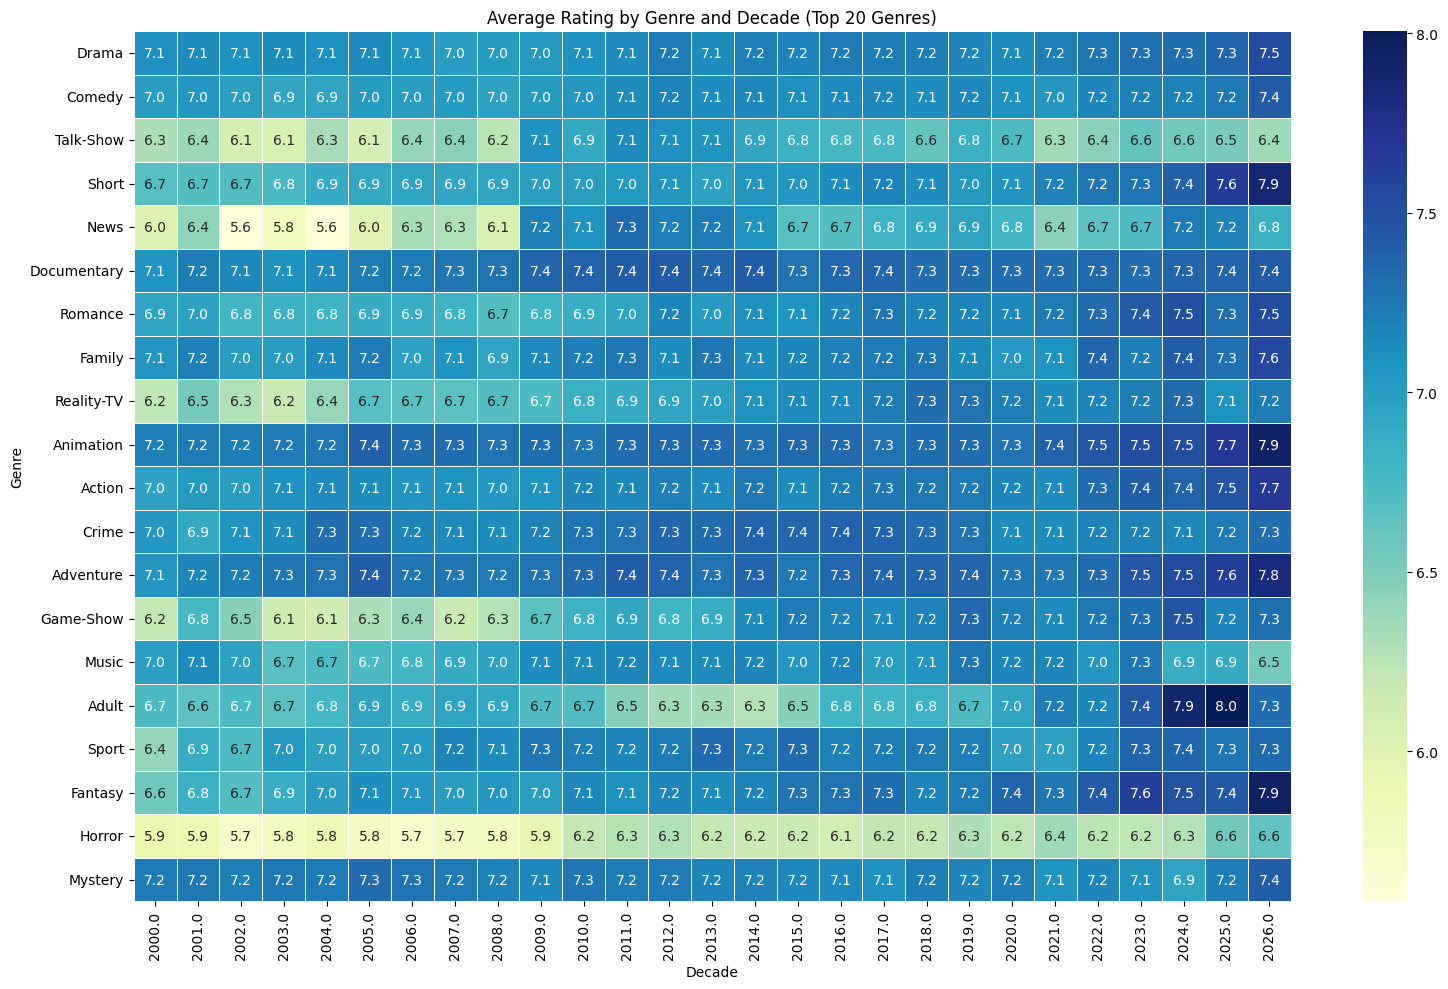

In [29]:
# Heatmap – average rating by decade and genre (limited categories)

# Step 1: Get top 20 genres by total title count (from the un-aggregated source)
top_genres_sql = """
    SELECT genre, COUNT(*) AS cnt
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre
        FROM dim_title
        WHERE genre_list IS NOT NULL
    )
    GROUP BY genre
    ORDER BY cnt DESC
    LIMIT 20
"""
top_genres = con.execute(top_genres_sql).df()['genre'].tolist()

# Step 2: Aggregate rating by decade and genre, but only for top genres and relevant decades
sql = """
    SELECT genre, decade, AVG(average_rating) AS avg_rating
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre,
               (start_year / 10) * 10 AS decade,
               average_rating
        FROM dim_title
        WHERE start_year IS NOT NULL AND genre_list IS NOT NULL AND average_rating IS NOT NULL
    )
    WHERE decade BETWEEN 2000 AND 2026
    GROUP BY genre, decade
"""
df_heat = con.execute(sql).df()

# Filter to only the top genres
df_heat = df_heat[df_heat['genre'].isin(top_genres)]

# Pivot for heatmap
heat_pivot = df_heat.pivot(index='genre', columns='decade', values='avg_rating')
# Sort genres by total count if desired (optional)
heat_pivot = heat_pivot.loc[top_genres]  # ensure order of top genres

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(heat_pivot, cmap='YlGnBu', annot=True, fmt='.1f', linewidths=.5, ax=ax)
ax.set_title('Average Rating by Genre and Decade (Top 20 Genres)')
ax.set_ylabel('Genre')
ax.set_xlabel('Decade')
plt.tight_layout()
plot_all['1.2_heatmap_genre_decade'] = fig

In [30]:
# Line chart - movies vs. TV series rating trends (aggregated)
sql = """
    SELECT start_year, title_type, AVG(average_rating) AS avg_rating
    FROM dim_title
    WHERE start_year IS NOT NULL AND average_rating IS NOT NULL
        AND title_type IN ('movie', 'tvSeries', 'tvMiniSeries')
    GROUP BY start_year, title_type
    ORDER BY start_year
"""

df_type_trend = con.execute(sql).df()

# Simplify to 'Movie' vs 'TV Series'
df_type_trend['broad'] = df_type_trend['title_type'].apply(lambda x: 'Movie' if x == 'movie' else 'TV Series')
df_agg = df_type_trend.groupby(['start_year','broad'])['avg_rating'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_agg, x='start_year', y='avg_rating', hue='broad', ax=ax)
ax.set_title('Rating Trends: Movies vs TV Series')
ax.set_xlabel('Start Year')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['1.2_movies_vs_tv'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell50.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 1.3: Runtime Analysis ####

In [31]:
# Histogram - runtime for movies only
sql = """
    SELECT runtime_minutes
    FROM dim_title
    WHERE title_type = 'movie'
      AND runtime_minutes IS NOT NULL
      AND runtime_minutes > 0
"""
df_runtime = con.execute(sql).df()

lower = df_runtime['runtime_minutes'].quantile(0.0003)
upper = df_runtime['runtime_minutes'].quantile(0.99)

df_runtime_filtered = df_runtime[
    (df_runtime['runtime_minutes'] >= lower) &
    (df_runtime['runtime_minutes'] <= upper)
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df_runtime_filtered, x='runtime_minutes', bins=40, kde=True, ax=ax)

ax.set_title(f'Distribution of Movie Runtime (≤99th percentile: {upper:.0f} min)')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Count')

plt.tight_layout()
plot_all['1.3_runtime_hist'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell52.png', dpi=150, bbox_inches='tight')
plt.close()


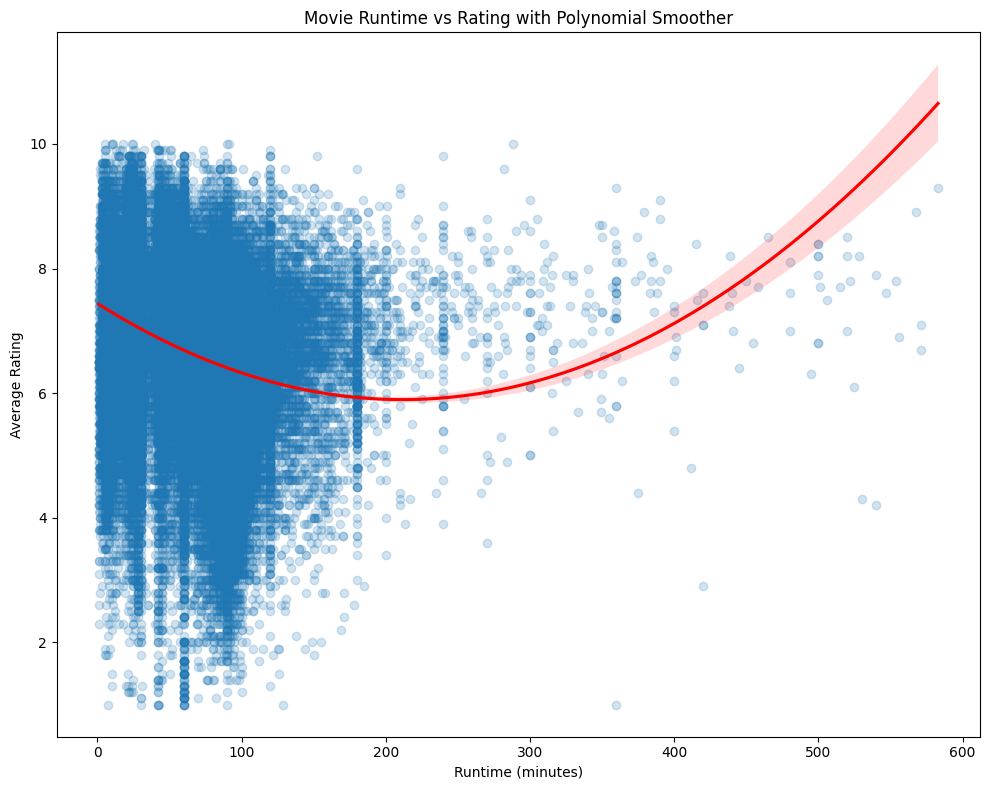

In [32]:
# Scatter runtime vs rating with LOESS (limited)
sql = """
    SELECT runtime_minutes, average_rating
    FROM dim_title
    WHERE runtime_minutes IS NOT NULL AND average_rating IS NOT NULL
        AND runtime_minutes > 0 AND runtime_minutes < 600
    LIMIT 100000
"""
df_scatter_rt = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 8))
sns.regplot(data=df_scatter_rt, x='runtime_minutes', y='average_rating',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, order=2, ax=ax)
ax.set_title('Movie Runtime vs Rating with Polynomial Smoother')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['1.3_runtime_vs_rating'] = fig

In [33]:
# Faceted box plots – runtime by genre
sql = """
    SELECT genre, runtime_minutes
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre, runtime_minutes
        FROM dim_title
        WHERE genre_list IS NOT NULL AND runtime_minutes > 0 AND runtime_minutes < 600
    )
    LIMIT 200000
"""
df_box_genre = con.execute(sql).df()

top_genres = df_box_genre['genre'].value_counts().head(15).index
df_plot = df_box_genre[df_box_genre['genre'].isin(top_genres)]

g = sns.catplot(data=df_plot, x='genre', y='runtime_minutes', kind='box',
                palette='Set3', aspect=2, height=6, hue='genre', legend=False)
g.set_xticklabels(rotation=45)
g.fig.suptitle('Runtime Distribution by Genre (Top 15)')
plt.tight_layout()
plot_all['1.3_runtime_box_genre'] = g.fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell54.png', dpi=150, bbox_inches='tight')
plt.close()


In [34]:
# Average runtime per decade (aggregated)
sql = """
    SELECT decade, AVG(runtime_minutes) AS avg_runtime
    FROM (
        SELECT (start_year / 10) * 10 AS decade, runtime_minutes
        FROM dim_title
        WHERE start_year IS NOT NULL AND runtime_minutes > 0 AND runtime_minutes < 600
    )
    GROUP BY decade
    ORDER BY decade
"""
df_decade_runtime = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_decade_runtime, x='decade', y='avg_runtime', marker='o', ax=ax)
ax.set_title('Average Movie Runtime per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Average Runtime (minutes)')
plt.tight_layout()
plot_all['1.3_runtime_per_decade'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell55.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 1.4: Episode Level Analysis for TV Series ####

In [35]:
# Average rating per season
sql = """
    SELECT e.season_number, AVG(d.average_rating) AS avg_rating, COUNT(*) AS ep_count
    FROM fact_episode e
    JOIN dim_title d ON e.episode_key = d.tconst
    WHERE d.average_rating IS NOT NULL AND e.season_number BETWEEN 1 AND 50
    GROUP BY e.season_number
    ORDER BY e.season_number
"""

df_season_avg = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=df_season_avg, x='season_number', y='avg_rating', ax=ax)
ax.set_title('Average Episode Rating by Season (All Series)')
ax.set_xlabel('Season Number')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['1.4_rating_per_season'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell57.png', dpi=150, bbox_inches='tight')
plt.close()


In [36]:
# Faceted line charts for high‑profile series
series_tconsts = con.execute("""
    SELECT tconst, primary_title
    FROM dim_title
    WHERE title_type IN ('tvSeries', 'tvMiniSeries')
      AND primary_title IN ('Game of Thrones', 'Breaking Bad', 'The Sopranos')
""").df()

episode_data = []
for _, row in series_tconsts.iterrows():
    series_tconst = row['tconst']
    series_name = row['primary_title']
    df_ep = con.execute(f"""
        SELECT e.season_number, e.episode_number, d.average_rating
        FROM fact_episode e
        JOIN dim_title d ON e.episode_key = d.tconst
        WHERE e.series_key = '{series_tconst}' AND d.average_rating IS NOT NULL
        ORDER BY e.season_number, e.episode_number
    """).df()
    df_ep['series'] = series_name
    episode_data.append(df_ep)

df_ep_all = pd.concat(episode_data, ignore_index=True)

g = sns.FacetGrid(df_ep_all, col='series', col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, 'episode_number', 'average_rating', 'season_number', palette='viridis')
g.set_axis_labels('Episode Number', 'Rating')
g.set_titles(col_template='{col_name}')
g.add_legend()
plt.tight_layout()
plot_all['1.4_faceted_series'] = g.fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell58.png', dpi=150, bbox_inches='tight')
plt.close()


In [37]:
# Box plot of episode ratings by season number
sql = """
    SELECT e.season_number, d.average_rating
    FROM fact_episode e TABLESAMPLE SYSTEM (5 percent) REPEATABLE (42)
    JOIN dim_title d ON e.episode_key = d.tconst
    WHERE d.average_rating IS NOT NULL AND e.season_number IS NOT NULL
      AND e.season_number <= 20
    LIMIT 50000
"""

df_ep_box = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_ep_box, x='season_number', y='average_rating', ax=ax)
ax.set_title('Episode Ratings by Season Number (sampled)')
ax.set_xlabel('Season')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['1.4_box_ep_by_season'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell59.png', dpi=150, bbox_inches='tight')
plt.close()


In [38]:
# Scatter: season vs. episode number coloured by rating
sql = """
    SELECT e.season_number, e.episode_number, d.average_rating
    FROM fact_episode e TABLESAMPLE SYSTEM (3 PERCENT) REPEATABLE (42)
    JOIN dim_title d ON e.episode_key = d.tconst
    WHERE d.average_rating IS NOT NULL
      AND e.season_number <= 30 AND e.episode_number <= 50
    LIMIT 200000
"""
df_ep_scatter = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(df_ep_scatter['season_number'], df_ep_scatter['episode_number'],
                c=df_ep_scatter['average_rating'], cmap='RdYlGn', alpha=0.6)
ax.set_title('Episode Grid: Season vs Episode Number Coloured by Rating (sampled)')
ax.set_xlabel('Season')
ax.set_ylabel('Episode Number')
plt.colorbar(sc, label='Average Rating')
plt.tight_layout()
plot_all['1.4_scatter_season_ep'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell60.png', dpi=150, bbox_inches='tight')
plt.close()


### Module 2: Principals, Crews & Persons ###

<center><i>“SNA, a data science discipline, provides a powerful framework for investigating these interactions by leveraging the power of networks and graph theory”</i></center><br>

The entertainment industry is fundamentally a cobweb of human relationships — collaborations between directors, writers, actors, and crew that produce the titles audiences consume. This module examines the people behind the titles.

#### Task 2.1: Director Influence Analysis ####

In [39]:
# Top 20 directors by number of titles
sql = """
    SELECT p.primary_name, COUNT(*) AS title_count
    FROM fact_performance f
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'director'
    GROUP BY p.primary_name
    ORDER BY title_count DESC
    LIMIT 20
"""
df_top_dir_count = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df_top_dir_count, x='title_count', y='primary_name', hue = 'primary_name', palette='magma', ax=ax, legend=False)
ax.set_title('Top 20 Directors by Number of Titles')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Director')
plt.tight_layout()
plot_all['2.1_top_directors_count'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell64.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [40]:
# Top 20 directors by average rating (>= 10 titles)
sql = """
    SELECT p.primary_name,
           AVG(d.average_rating) AS avg_rating,
           COUNT(*) AS n
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'director'
      AND d.average_rating IS NOT NULL
    GROUP BY p.primary_name
    HAVING COUNT(*) >= 10
    ORDER BY avg_rating DESC
    LIMIT 20
"""
df_top_dir_rating = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(data=df_top_dir_rating, x='avg_rating', y='primary_name', s=80, color='darkred', ax=ax)

ax.set_title('Top 20 Directors by Average Rating (min 10 titles)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Director')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plot_all['2.1_top_directors_rating'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell65.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [41]:
# Scatter: productivity vs quality (limited to 5000)
sql = """
    SELECT p.primary_name,
           COUNT(*) AS title_count,
           AVG(d.average_rating) AS avg_rating
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'director'
      AND d.average_rating IS NOT NULL
    GROUP BY p.primary_name
    HAVING COUNT(*) >= 5
    ORDER BY title_count DESC
    LIMIT 5000
"""
df_dir_scatter = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df_dir_scatter['title_count'], df_dir_scatter['avg_rating'],
                alpha=0.6, c=df_dir_scatter['avg_rating'], cmap='viridis')
ax.set_xscale('log')
ax.set_xlabel('Number of Titles Directed (log scale)')
ax.set_ylabel('Average Rating')
ax.set_title('Productivity vs Quality for Directors (Min 5 titles)')
plt.colorbar(sc, label='Avg Rating')
plt.tight_layout()
plot_all['2.1_director_scatter'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell66.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

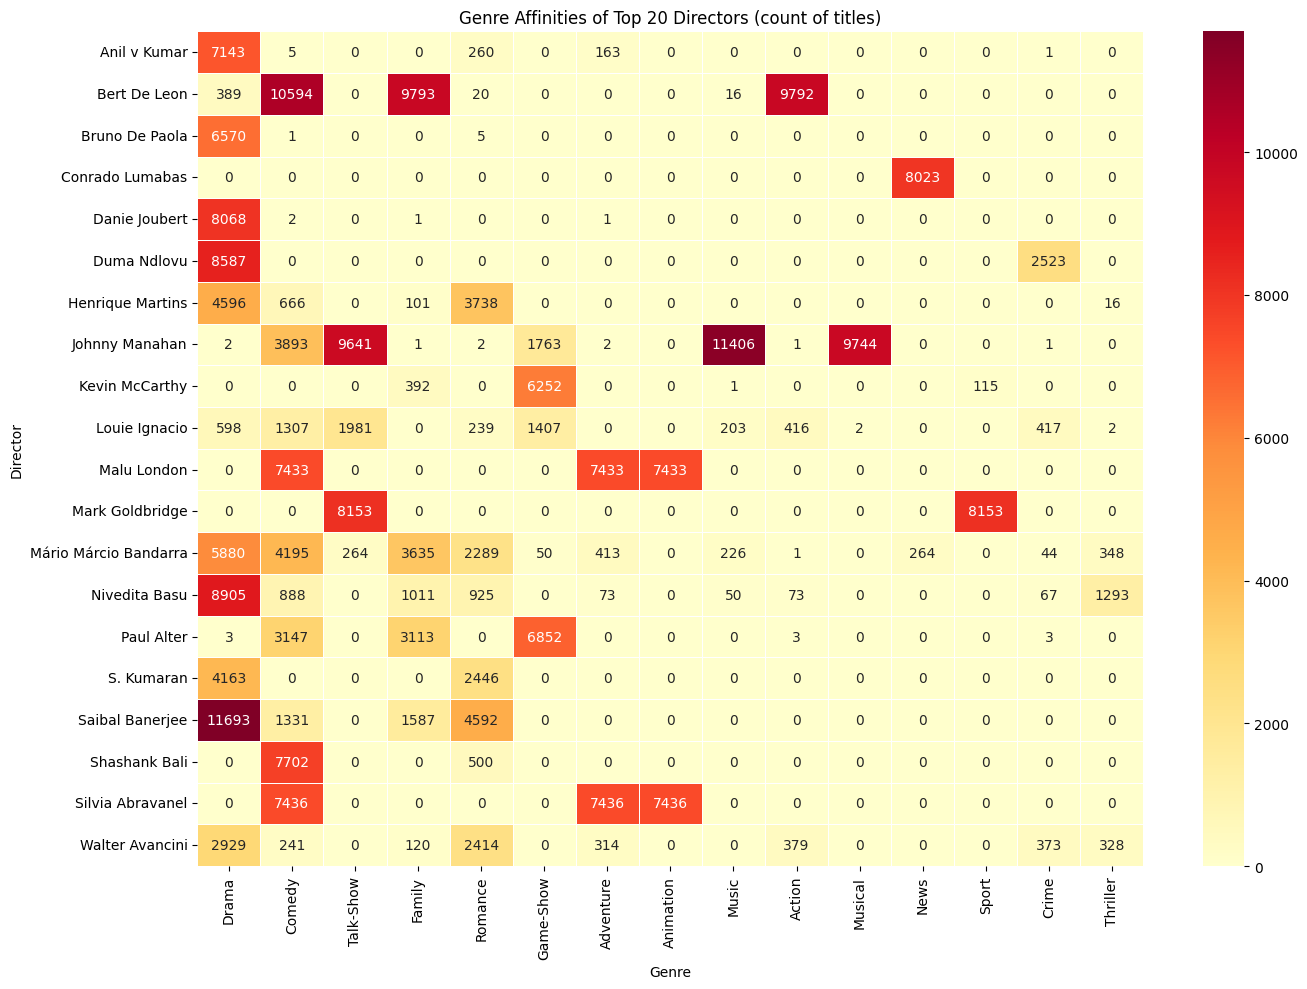

In [42]:
# Director genre affinities (heatmap)
# We first find the top 20 directors, then for each we count genres
# By unnesting their titles' genre_list, all inside SQL
# The final cross-tab is pivoted in Python, but data volume is tiny
sql = """
    WITH top_directors AS (
        SELECT p.nconst, p.primary_name, COUNT(*) AS cnt
        FROM fact_performance f
        JOIN dim_person p ON f.nconst = p.nconst
        WHERE f.category = 'director'
        GROUP BY p.nconst, p.primary_name
        ORDER BY cnt DESC
        LIMIT 20
    )
    SELECT d.primary_name AS director,
           genre,
           COUNT(*) AS genre_count
    FROM (
        SELECT f.nconst, unnest(string_split(d.genre_list, ',')) AS genre
        FROM fact_performance f
        JOIN dim_title d ON f.tconst = d.tconst
        WHERE f.category = 'director'
          AND d.genre_list IS NOT NULL
          AND f.nconst IN (SELECT nconst FROM top_directors)
    ) t
    JOIN top_directors d ON t.nconst = d.nconst
    GROUP BY d.primary_name, genre
    ORDER BY director, genre_count DESC
"""
df_dir_genre_agg = con.execute(sql).df()

# Pivot to heatmap matrix (directors × genres), keep only top 15 genres overall
heat_data = df_dir_genre_agg.pivot(index='director', columns='genre', values='genre_count').fillna(0)
top_genres = heat_data.sum().sort_values(ascending=False).head(15).index
heat_data = heat_data[top_genres]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5, ax=ax)
ax.set_title('Genre Affinities of Top 20 Directors (count of titles)')
ax.set_xlabel('Genre')
ax.set_ylabel('Director')
plt.tight_layout()
plot_all['2.1_director_genre_heatmap'] = fig

#### Task 2.2: Actor Collaboration Networks ####

In [43]:
# Network graph of actor co-occurrence (top 500 actors, edges >= 2)

top_actor_sql = """
    SELECT f.nconst, p.primary_name
    FROM fact_performance f
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'actor'
    GROUP BY f.nconst, p.primary_name
    ORDER BY COUNT(*) DESC
    LIMIT 500
"""
top_actors = con.execute(top_actor_sql).df()
top_nconsts = top_actors['nconst'].tolist()

top_nconst_str = ', '.join(f"'{n}'" for n in top_nconsts)

edges_sql = f"""
    SELECT a.nconst AS actor1, b.nconst AS actor2, COUNT(*) AS weight
    FROM fact_performance a
    JOIN fact_performance b
      ON a.tconst = b.tconst
     AND a.nconst < b.nconst
    WHERE a.category = 'actor'
      AND b.category = 'actor'
      AND a.nconst IN ({top_nconst_str})
      AND b.nconst IN ({top_nconst_str})
    GROUP BY actor1, actor2
    HAVING COUNT(*) >= 2
    ORDER BY weight DESC
"""

edges = con.execute(edges_sql).df()

# Build graph
G = nx.Graph()
G.add_nodes_from(top_actors['nconst'])
G.add_weighted_edges_from(
    edges[['actor1', 'actor2', 'weight']].itertuples(index=False)
)
G.remove_nodes_from(list(nx.isolates(G)))

# Node size by degree centrality
degree_cent = nx.degree_centrality(G)
node_sizes = [100 + degree_cent[n] * 2500 for n in G.nodes()]

# Community detection
communities = community.louvain_communities(G, seed=42)

color_map = {
    node: i
    for i, comm in enumerate(communities)
    for node in comm
}

n_communities = len(communities)
community_cmap = plt.colormaps.get_cmap('tab20').resampled(n_communities)

node_colors = [community_cmap(color_map[n]) for n in G.nodes()]

# Draw graph
fig, ax = plt.subplots(figsize=(15, 10))

pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

nx.draw_networkx_edges(G, pos, alpha=0.08, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85, ax=ax)

# ---------- Ranked list of top actors ----------
top_nodes = sorted(degree_cent, key=degree_cent.get, reverse=True)[:20]

name_lookup = top_actors.set_index('nconst')['primary_name']

legend_text = "Top 20 Actors\n(by Degree Centrality)\n\n"
legend_text += "\n".join(f"{i+1:>2}. {name_lookup[n]}" for i, n in enumerate(top_nodes))

ax.text(1.02, 1.0, "Top 20 Actors\n(By Degree Centrality)", transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

y = 0.92

for i, node in enumerate(top_nodes, start=1):
    ax.scatter(1.025, y, s=60, color=community_cmap(color_map[node]), transform=ax.transAxes, clip_on=False)
    ax.text(1.05, y, f"{i:>2}. {name_lookup[node]}", transform=ax.transAxes, fontsize=8, va='center', family='monospace')
    y -= 0.025

ax.set_title('Actor Collaboration Network (Top 500 Actors, Edges ≥ 2)')
ax.axis('off')

plt.subplots_adjust(right=0.78)   # leave room for text box

plot_all['2.2_actor_network'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell69.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [44]:
# Top 20 actors by degree centrality (from network)
degree_df = pd.DataFrame({'nconst': list(degree_cent.keys()), 'centrality': list(degree_cent.values())})
degree_df = degree_df.merge(top_actors[['nconst','primary_name']], on='nconst')
top_degree = degree_df.sort_values('centrality', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_degree, x='centrality', y='primary_name', hue='primary_name', palette='plasma', ax=ax)
ax.set_title('Top 20 Actors by Degree Centrality')
ax.set_xlabel('Degree Centrality')
ax.set_ylabel('Actor')
plt.tight_layout()
plot_all['2.2_top_actors_centrality'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell70.png', dpi=150, bbox_inches='tight')
plt.close()


In [45]:
# Top 20 actors by average rating (min 10 titles, aggregated)
sql = """
    SELECT p.primary_name,
           AVG(d.average_rating) AS avg_rating,
           COUNT(*) AS n
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'actor'
      AND d.average_rating IS NOT NULL
    GROUP BY p.primary_name
    HAVING COUNT(*) >= 10
    ORDER BY avg_rating DESC
    LIMIT 20
"""
df_top_actor_rating = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(data=df_top_actor_rating, x='avg_rating', y='primary_name', s=100, color='steelblue', ax=ax)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_title('Top 20 Actors by Average Rating (min 10 titles)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Actor')
plt.tight_layout()
plot_all['2.2_top_actors_rating'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell71.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [46]:
# ---------- Actor communities graph ----------
large_comm = [c for c in communities if len(c) > 5]
sub_nodes = [node for comm in large_comm for node in comm]
sub_G = G.subgraph(sub_nodes).copy()

comm_mapping = {
    node: i
    for i, comm in enumerate(large_comm)
    for node in comm
}

node_colors_sub = [comm_mapping[n] for n in sub_G.nodes()]

fig, ax = plt.subplots(figsize=(15, 12))

pos = nx.spring_layout(sub_G, k=0.12, iterations=50, seed=42)

# Edges
nx.draw_networkx_edges(sub_G, pos, alpha=0.08, edge_color='gray', ax=ax)

# Nodes
nx.draw_networkx_nodes(sub_G, pos, node_size=100, node_color=node_colors_sub, cmap=plt.cm.tab10, alpha=0.85, ax=ax)

# ---------- Community legend ----------
community_sizes = {
    i: len(comm)
    for i, comm in enumerate(large_comm)
}

legend_text = "Actor Communities\n(Louvain)\n\n"

for i, size in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True):
    legend_text += f"{i+1:>2}. Community {i+1}: {size} actors\n"

ax.text(1.02, 1.0, "Actor Communities\n(Louvain)", transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

y = 0.92

for i, size in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True):
    ax.scatter(1.025, y, s=80, color=plt.cm.tab10(i % 10), transform=ax.transAxes, clip_on=False)
    ax.text(1.05, y, f"Community {i+1}: {size} actors", transform=ax.transAxes, fontsize=8, va='center', family='monospace')
    y -= 0.025

ax.set_title('Actor Communities (Louvain, communities > 5 members)')
ax.axis('off')

plt.subplots_adjust(right=0.75)
plot_all['2.2_actor_communities'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell72.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 2.3: Writer and Crew Analysis ####

In [47]:
# Top 20 writers by number of titles
sql = """
    SELECT p.primary_name, COUNT(*) AS title_count
    FROM fact_performance f
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'writer'
    GROUP BY p.primary_name
    ORDER BY title_count DESC
    LIMIT 20
"""
df_top_writer_count = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df_top_writer_count, x='title_count', y='primary_name', hue='primary_name', palette='magma', ax=ax)
ax.set_title('Top 20 Writers by Number of Titles')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Writer')
plt.tight_layout()
plot_all['2.3_top_writers_count'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell74.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [48]:
# Top 20 writers by average rating (>= 5 titles, aggregated)
sql = """
    SELECT p.primary_name,
           AVG(d.average_rating) AS avg_rating,
           COUNT(*) AS n
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    JOIN dim_person p ON f.nconst = p.nconst
    WHERE f.category = 'writer'
      AND d.average_rating IS NOT NULL
    GROUP BY p.primary_name
    HAVING COUNT(*) >= 5
    ORDER BY avg_rating DESC
    LIMIT 20
"""
dF_top_writer_rating = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=dF_top_writer_rating, x='avg_rating', y='primary_name', s=100, color='darkred', ax=ax)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_title('Top 20 Writers by Average Rating (min 5 titles)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Writer')
plt.tight_layout()
plot_all['2.3_top_writers_rating'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell75.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [49]:
# Writer-Director collaboration heatmap (aggregated in DuckDB, small result)
sql = """
    SELECT w.nconst AS writer_nconst, d.nconst AS director_nconst,
           p_w.primary_name AS writer_name, p_d.primary_name AS director_name,
           COUNT(*) AS collab_count
    FROM fact_performance w
    JOIN fact_performance d ON w.tconst = d.tconst
    JOIN dim_person p_w ON w.nconst = p_w.nconst
    JOIN dim_person p_d ON d.nconst = p_d.nconst
    WHERE w.category = 'writer' AND d.category = 'director'
    GROUP BY w.nconst, d.nconst, p_w.primary_name, p_d.primary_name
    HAVING COUNT(*) >= 3
    ORDER BY collab_count DESC
    LIMIT 100
"""
df_pairs = con.execute(sql).df()

top_writers = df_pairs.groupby('writer_name')['collab_count'].sum().nlargest(15).index
top_directors = df_pairs.groupby('director_name')['collab_count'].sum().nlargest(15).index
heatmap_data = df_pairs[(df_pairs['writer_name'].isin(top_writers)) & 
                        (df_pairs['director_name'].isin(top_directors))]
pivot = heatmap_data.pivot_table(index='writer_name', columns='director_name', 
                                 values='collab_count', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=.5, ax=ax)
ax.set_title('Top Writer–Director Collaboration Pairs (≥3 shared titles)')
ax.set_xlabel('Director')
ax.set_ylabel('Writer')
plt.tight_layout()
plot_all['2.3_writer_director_heatmap'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell76.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [50]:
# Scatter: pair frequency vs average rating (limited to 2000 pairs)
sql = """
    SELECT w.nconst AS writer, d.nconst AS director,
           COUNT(*) AS freq,
           AVG(t.average_rating) AS avg_rating
    FROM fact_performance w
    JOIN fact_performance d ON w.tconst = d.tconst
    JOIN dim_title t ON w.tconst = t.tconst
    WHERE w.category = 'writer' AND d.category = 'director'
      AND t.average_rating IS NOT NULL
    GROUP BY writer, director
    HAVING COUNT(*) >= 3
    LIMIT 2000
"""
df_pair_scatter = con.execute(sql).df()

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df_pair_scatter['freq'], df_pair_scatter['avg_rating'],
                alpha=0.5, c=df_pair_scatter['avg_rating'], cmap='coolwarm')
ax.set_xscale('log')
ax.set_xlabel('Number of Collaborative Titles (log scale)')
ax.set_ylabel('Average Rating')
ax.set_title('Writer–Director Pair Frequency vs. Average Rating')
plt.colorbar(sc, label='Avg Rating')
plt.tight_layout()
plot_all['2.3_pair_freq_vs_rating'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell77.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Task 2.4: Career Trajectories and Longevity ####

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

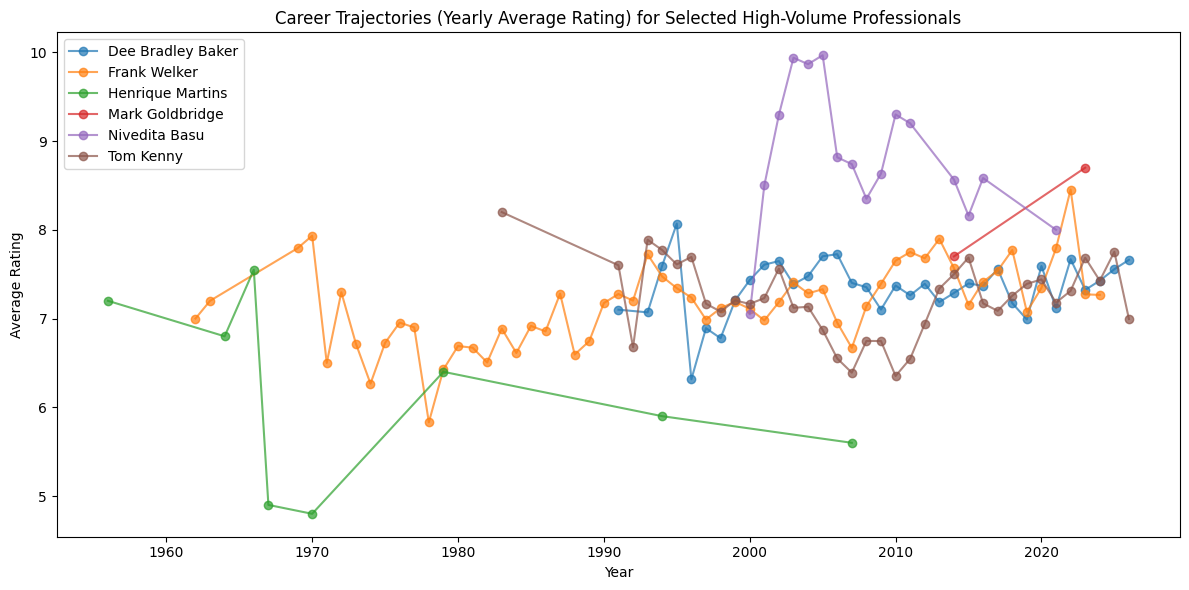

In [51]:
# Career trajectories for top‑6 high‑volume professionals (aggregated)
famous = con.execute("""
    SELECT p.nconst, p.primary_name, MIN(d.start_year) AS first_year
    FROM fact_performance f
    JOIN dim_person p ON f.nconst = p.nconst
    JOIN dim_title d ON f.tconst = d.tconst
    WHERE (f.category IN ('director', 'actor'))
      AND d.start_year IS NOT NULL
    GROUP BY p.nconst, p.primary_name
    ORDER BY COUNT(*) DESC
    LIMIT 6
""").df()

trajectories = []
for _, row in famous.iterrows():
    nconst = row['nconst']
    name = row['primary_name']
    df = con.execute(f"""
        SELECT d.start_year, AVG(d.average_rating) AS avg_rating
        FROM fact_performance f
        JOIN dim_title d ON f.tconst = d.tconst
        WHERE f.nconst = '{nconst}'
          AND d.start_year IS NOT NULL
          AND d.average_rating IS NOT NULL
        GROUP BY d.start_year
        ORDER BY d.start_year
    """).df()
    df['name'] = name
    trajectories.append(df)

df_traj = pd.concat(trajectories, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
for name, grp in df_traj.groupby('name'):
    ax.plot(grp['start_year'], grp['avg_rating'], '-o', label=name, alpha=0.7)
ax.legend()
ax.set_title('Career Trajectories (Yearly Average Rating) for Selected High-Volume Professionals')
ax.set_xlabel('Year')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['2.4_career_trajectories'] = fig

In [52]:
# Histogram of career length (limited to 50k)
sql = """
    SELECT category,
           MAX(start_year) - MIN(start_year) + 1 AS career_length
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    WHERE f.category IN ('director', 'actor')
      AND d.start_year IS NOT NULL
    GROUP BY f.nconst, f.category
    HAVING COUNT(DISTINCT d.start_year) >= 2
    LIMIT 50000
"""
df_career_len = con.execute(sql).df()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for i, cat in enumerate(['director','actor']):
    subset = df_career_len[df_career_len['category'] == cat]['career_length']
    axes[i].hist(subset, bins=40, color='teal' if cat=='director' else 'orange', alpha=0.7)
    axes[i].set_title(f'Career Length – {cat}s')
    axes[i].set_xlabel('Years')
    axes[i].set_ylabel('Count')
    axes[i].set_xlim(0, 80)
plt.suptitle('Histogram of Career Lengths')
plt.tight_layout()
plot_all['2.4_career_length_hist'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell80.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [53]:
# Debut year vs time to peak rating (limited to 10k)
sql = """
    SELECT f.nconst, f.category,
           MIN(d.start_year) AS debut_year,
           (ARRAY_AGG(d.start_year ORDER BY d.average_rating DESC))[1] AS peak_rating_year
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    WHERE f.category IN ('director', 'actor')
      AND d.start_year IS NOT NULL
      AND d.average_rating IS NOT NULL
    GROUP BY f.nconst, f.category
    HAVING COUNT(*) >= 5
    LIMIT 10000
"""
df_peak = con.execute(sql).df()
df_peak['time_to_peak'] = df_peak['peak_rating_year'] - df_peak['debut_year']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for i, cat in enumerate(['director','actor']):
    subset = df_peak[df_peak['category'] == cat]
    axes[i].scatter(subset['debut_year'], subset['time_to_peak'], alpha=0.5, s=10)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'{cat.capitalize()}: Debut Year vs. Time to Peak Rating')
    axes[i].set_xlabel('Debut Year')
    axes[i].set_ylabel('Years to Peak Rating')
plt.tight_layout()
plot_all['2.4_debut_vs_peak'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell81.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [54]:
# Survival curves
sql = """
    SELECT f.nconst, f.category,
           MIN(d.start_year) AS first_year,
           MAX(d.start_year) AS last_year
    FROM fact_performance f
    JOIN dim_title d ON f.tconst = d.tconst
    WHERE f.category IN ('director', 'actor')
      AND d.start_year IS NOT NULL
    GROUP BY f.nconst, f.category
"""
df_career = con.execute(sql).df()
df_career["career_length"] = df_career["last_year"] - df_career["first_year"]

max_t = 60
surv_director = []
surv_actor = []
for t in range(1, max_t+1):
    surv_director.append((df_career[df_career['category']=='director']['career_length'] > t).mean())
    surv_actor.append((df_career[df_career['category']=='actor']['career_length'] > t).mean())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, max_t+1), surv_director, label='Directors', color='teal')
ax.plot(range(1, max_t+1), surv_actor, label='Actors', color='orange')
ax.set_xlabel('Years Since Debut')
ax.set_ylabel('Fraction Still Active')
ax.set_title('Career Survival Curves (Kaplan–Meier style)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plot_all['2.4_survival_curves'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell82.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Module 3: Miscellaneous ###

<i><center> “The Entertainment sector is a fluid market where changing audience tastes are the driving force” </center></i><br>

This module addresses specialised aspects of the IMDb data that do not fit neatly into the title level or person level categories: documentaries, international distribution, regional variations, and the broader economics of the industry.

#### Task 3.1: Documentary Film Analysis ####

In [55]:
# Average rating of documentaries vs other title types (aggregated, safe)
doc_sql = """
    SELECT
        CASE WHEN genre_list LIKE '%Documentary%' THEN 'Documentary' ELSE 'Other' END AS doc_flag,
        title_type,
        AVG(average_rating) AS avg_rating,
        COUNT(*) AS cnt
    FROM dim_title
    WHERE average_rating IS NOT NULL AND title_type IN ('movie', 'tvSeries', 'short')
    GROUP BY doc_flag, title_type
    ORDER BY doc_flag, title_type
"""
df_doc = con.execute(doc_sql).df()

df_pivot = df_doc.pivot(index='title_type', columns='doc_flag', values='avg_rating').fillna(0)
fig, ax = plt.subplots(figsize=(8, 6))
df_pivot.plot(kind='bar', ax=ax, color=['orange', 'teal'])
ax.set_title('Average Rating: Documentaries vs. Other Titles')
ax.set_ylabel('Average Rating')
ax.set_xlabel('Title Type')
plt.xticks(rotation=0)
ax.legend(title='Content Type', labels=['Documentary', 'Other'], loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=9, title_fontsize=10)
plt.tight_layout()
plot_all['3.1_doc_vs_other_ratings'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell86.png', dpi=150, bbox_inches='tight')
plt.close()


In [56]:
# Number of documentary titles per year (aggregated, safe)
doc_year_sql = """
    SELECT start_year, COUNT(*) AS doc_count
    FROM dim_title
    WHERE genre_list LIKE '%Documentary%'
      AND start_year IS NOT NULL
    GROUP BY start_year
    ORDER BY start_year
"""
df_doc_year = con.execute(doc_year_sql).df()

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df_doc_year, x='start_year', y='doc_count', ax=ax)
ax.set_title('Number of Documentary Titles Released per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Title Count')
plt.tight_layout()
plot_all['3.1_doc_year_counts'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell87.png', dpi=150, bbox_inches='tight')
plt.close()


In [57]:
# Top documentary sub-genres (aggregated, safe)
doc_genre_sql = """
    SELECT genre, COUNT(*) AS cnt
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre
        FROM dim_title
        WHERE genre_list LIKE '%Documentary%'
          AND genre_list IS NOT NULL
    )
    GROUP BY genre
    ORDER BY cnt DESC
    LIMIT 15
"""
df_docs_genres = con.execute(doc_genre_sql).df()

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(data=df_docs_genres, x='cnt', y='genre', hue='genre', palette='viridis', ax=ax, legend=False)
ax.set_title('Top Documentary Sub‑Genres')
ax.set_xlabel('Title Count')
ax.set_ylabel('Genre')
plt.tight_layout()
plot_all['3.1_doc_subgenres'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell88.png', dpi=150, bbox_inches='tight')
plt.close()


In [58]:
# Scatter: documentary runtime vs. rating vs. fiction (sampled with TABLESAMPLE SYSTEM)
doc_scatter_sql = """
    SELECT
        CASE 
            WHEN genre_list LIKE '%Documentary%' THEN 'Documentary'
            ELSE 'Fiction'
        END AS doc_flag,
        runtime_minutes,
        average_rating
    FROM dim_title TABLESAMPLE SYSTEM (1 PERCENT) REPEATABLE(42)
    WHERE runtime_minutes > 0
      AND runtime_minutes < 1000
      AND average_rating IS NOT NULL
    LIMIT 20000
"""
df_doc_scatter = con.execute(doc_scatter_sql).df()

# Split data
df_doc = df_doc_scatter[df_doc_scatter['doc_flag'] == 'Documentary']
df_other = df_doc_scatter[df_doc_scatter['doc_flag'] == 'Fiction']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Documentary scatter
sns.scatterplot(data=df_doc, x='runtime_minutes', y='average_rating', color='teal', alpha=0.5, ax=axes[0])
axes[0].set_title('Documentary')
axes[0].set_xlabel('Runtime (minutes)')
axes[0].set_ylabel('Average Rating')

# Other titles scatter
sns.scatterplot(data=df_other, x='runtime_minutes', y='average_rating', color='orange', alpha=0.5, ax=axes[1])
axes[1].set_title('Fiction')
axes[1].set_xlabel('Runtime (minutes)')
axes[1].set_ylabel('')

fig.suptitle('Runtime vs. Rating: Documentary vs. Fiction', fontsize=14, y=1.02)
plt.tight_layout()
plot_all['3.1_doc_runtime_scatter'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell89.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 3.2: International Distribution and Regional Patterns ####

Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


...

Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


Query failed: 'NoneType' object has no attribute 'alpha_3'


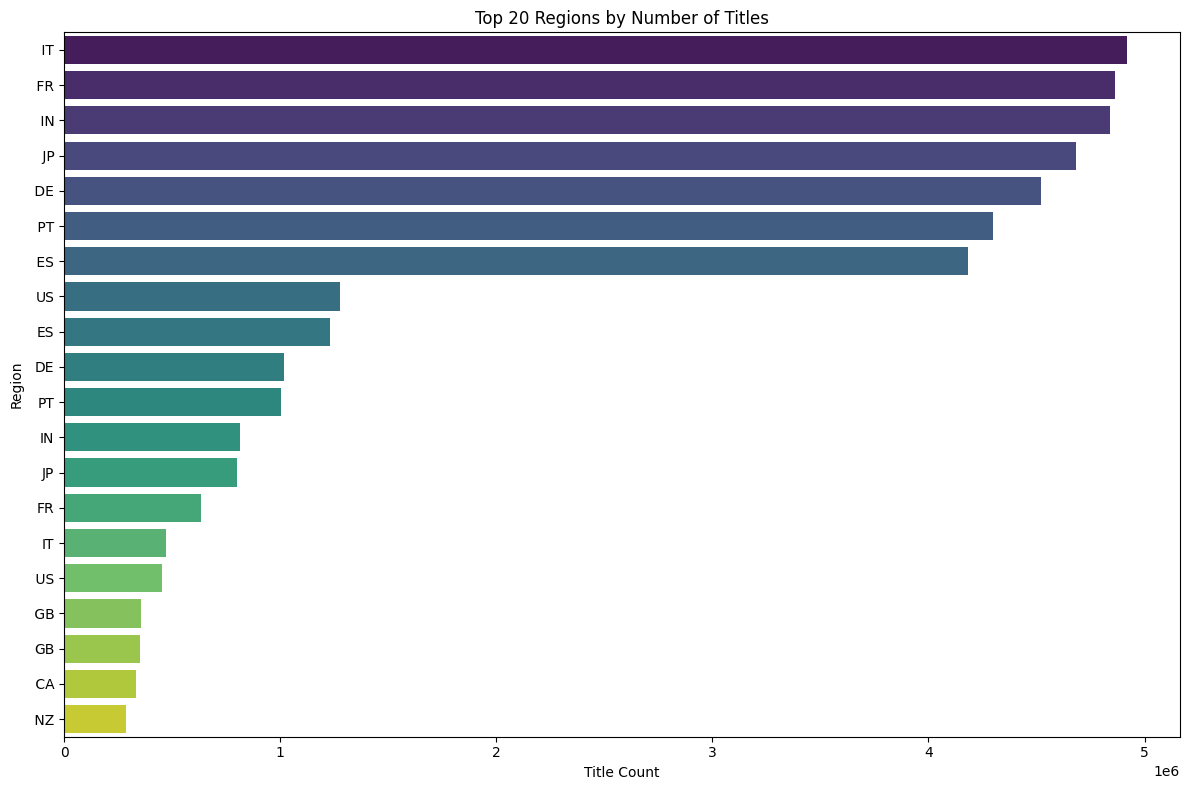

In [59]:

# Cloropleth map - number of title per region

# First, get region counts (aggregated, safe)
region_counts_sql = """
    SELECT region, COUNT(*) AS title_count
    FROM (
        SELECT unnest(string_split(region_list, ',')) AS region
        FROM dim_title
        WHERE region_list IS NOT NULL AND region_list != ''
    )
    GROUP BY region
    ORDER BY title_count DESC
"""
df_region_counts = con.execute(region_counts_sql).df()

# For Plotly choropleth, we need ISO 3166-1 alpha‑3 codes.
# IMDb region codes are alpha‑2 (e.g., 'US','GB'). We'll convert them.
# If pycountry is not installed, fall back to a bar chart.
try:
    import pycountry

    def alpha2_to_alpha3(code):
        try:
            return pycountry.countries.get(alpha_2=code).alpha_3
        except Exception as e:
            logger.warning(f"Query failed: {e}")
            return None

    df_region_counts['iso_alpha3'] = df_region_counts['region'].apply(alpha2_to_alpha3)
    # Drop regions that couldn't be mapped
    df_map = df_region_counts.dropna(subset=['iso_alpha3'])

    import plotly.express as px

    fig = px.choropleth(
        df_map,
        locations='iso_alpha3',
        locationmode='ISO-3',
        color='title_count',
        color_continuous_scale='Viridis',
        title='Number of Titles per Region (ISO‑3, alpha‑3)',
        labels={'title_count': 'Title Count'}
    )
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

    # Also create a static bar chart as backup
    top_regions = df_region_counts.head(20)
    fig2, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_regions, x='title_count', y='region', hue='region', palette='viridis', ax=ax)
    ax.set_title('Top 20 Regions by Number of Titles')
    ax.set_xlabel('Title Count')
    ax.set_ylabel('Region')
    plt.tight_layout()
    plot_all['3.2_region_counts'] = fig2

except ImportError:
    # Fallback: pycountry not available, use bar chart
    top_regions = df_region_counts.head(20)
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_regions, x='title_count', y='region', hue='region', palette='viridis', ax=ax)
    ax.set_title('Top 20 Regions by Number of Titles')
    ax.set_xlabel('Title Count')
    ax.set_ylabel('Region')
    plt.tight_layout()
    plot_all['3.2_region_counts'] = fig

In [60]:
# Bar chart of top regions by number of alternative titles

# dim_title.aka_count is already the count of alternative titles per title.
# To get top regions by alternative titles, we need to aggregate aka_count per region.
alt_titles_sql = """
    SELECT region, SUM(aka_count) AS total_aka
    FROM (
        SELECT unnest(string_split(region_list, ',')) AS region, aka_count
        FROM dim_title
        WHERE region_list IS NOT NULL AND region_list != ''
          AND aka_count IS NOT NULL
    )
    GROUP BY region
    ORDER BY total_aka DESC
    LIMIT 20
"""
df_alt = con.execute(alt_titles_sql).df()

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_alt, x='total_aka', y='region', hue='region', palette='magma', ax=ax)
ax.set_title('Top 20 Regions by Total Alternative Titles (AKA count)')
ax.set_xlabel('Total Alternative Titles')
ax.set_ylabel('Region')
plt.tight_layout()
plot_all['3.2_aka_region_counts'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell92.png', dpi=150, bbox_inches='tight')
plt.close()


In [61]:
# Heatmap - language-region associations

# We'll use the top 20 languages and top 20 regions by frequency, then pivot.
lang_region_sql = """
    SELECT language, region, COUNT(*) AS cnt
    FROM (
        SELECT unnest(string_split(language_list, ',')) AS language,
               unnest(string_split(region_list, ',')) AS region
        FROM dim_title
        WHERE language_list IS NOT NULL AND language_list != ''
          AND region_list IS NOT NULL AND region_list != ''
    )
    GROUP BY language, region
    ORDER BY cnt DESC
"""
df_lr = con.execute(lang_region_sql).df()

# Keep only top languages and regions by total count
top_languages = df_lr.groupby('language')['cnt'].sum().nlargest(20).index
top_regions_hm = df_lr.groupby('region')['cnt'].sum().nlargest(20).index
df_hm = df_lr[(df_lr['language'].isin(top_languages)) & (df_lr['region'].isin(top_regions_hm))]
hm_pivot = df_hm.pivot(index='language', columns='region', values='cnt').fillna(0)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(hm_pivot, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5, ax=ax)
ax.set_title('Language–Region Association (Top 20 languages & regions)')
ax.set_xlabel('Region')
ax.set_ylabel('Language')
plt.tight_layout()
plot_all['3.2_language_region_heatmap'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell93.png', dpi=150, bbox_inches='tight')
plt.close()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [62]:
# Scatter: region title count vs. average rating
region_rating_sql = """
    SELECT region,
           COUNT(*) AS title_count,
           AVG(average_rating) AS avg_rating
    FROM (
        SELECT unnest(string_split(region_list, ',')) AS region,
               average_rating
        FROM dim_title
        WHERE region_list IS NOT NULL AND region_list != ''
          AND average_rating IS NOT NULL
    )
    GROUP BY region
    HAVING COUNT(*) >= 10
"""
df_region_rating = con.execute(region_rating_sql).df()

fig, ax = plt.subplots(figsize=(12, 8))

scatter = sns.scatterplot(
    data=df_region_rating,
    x="title_count",
    y="avg_rating",
    size="title_count",
    hue="avg_rating",
    palette="viridis",
    sizes=(40, 500),
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6,
    legend=False,
    ax=ax
)

# Log scale
ax.set_xscale("log")

# Better tick formatting
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{int(x):,}"))

# Labels
ax.set_xlabel("Number of Titles (log scale)", fontsize=12)
ax.set_ylabel("Average IMDb Rating", fontsize=12)

ax.set_title("Average IMDb Rating by Region", fontsize=16, weight="bold", pad=15)

ax.text(0, 1.02, "Regions with at least 10 titles", transform=ax.transAxes, fontsize=11, color="dimgray")

# Annotate highest-rated regions
top_regions = (df_region_rating.sort_values("avg_rating", ascending=False).head(10))

for _, row in top_regions.iterrows():
    ax.annotate(
        row["region"],
        (row["title_count"], row["avg_rating"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="lightgray",
            alpha=0.8
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.6
        )
    )

sns.regplot(data=df_region_rating, x="title_count", y="avg_rating", scatter=False, logx=True, color="red", ci=None, ax=ax)

# Cleaner appearance
sns.despine()
ax.grid(alpha=0.25)
plt.tight_layout()
plot_all["3.2_region_rating_scatter"] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell94.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 3.3: Title Type Comparisons ####

In [63]:
# Box plot of average_rating by title_type (sampled)
type_rating_sql = """
    SELECT title_type, average_rating
    FROM dim_title TABLESAMPLE SYSTEM (1 PERCENT) REPEATABLE(42)
    WHERE average_rating IS NOT NULL
      AND title_type IN ('movie','tvSeries','tvMiniSeries','short','video','tvEpisode')
    LIMIT 50000
"""
df_type_rating = con.execute(type_rating_sql).df()

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df_type_rating, x='title_type', hue='title_type', y='average_rating', palette='Set2', ax=ax)
ax.set_title('Rating Distribution by Title Type')
ax.set_xlabel('Title Type')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['3.3_title_type_box'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell96.png', dpi=150, bbox_inches='tight')
plt.close()


In [64]:
# Count of titles by title_type (aggregated, safe)
type_count_sql = """
    SELECT title_type, COUNT(*) AS cnt
    FROM dim_title
    GROUP BY title_type
    ORDER BY cnt DESC
"""
df_type_count = con.execute(type_count_sql).df()

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=df_type_count, x='cnt', y='title_type', hue='title_type', palette='magma', ax=ax)
ax.set_title('Number of Titles per Title Type')
ax.set_xlabel('Count')
ax.set_ylabel('Title Type')
plt.tight_layout()
plot_all['3.3_title_type_counts'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell97.png', dpi=150, bbox_inches='tight')
plt.close()


In [65]:
# Scatter: num_votes vs rating faceted by title_type (sampled)
scatter_type_sql = """
    SELECT title_type, num_votes, average_rating
    FROM dim_title TABLESAMPLE SYSTEM (1 PERCENT) REPEATABLE(42)
    WHERE num_votes > 0 AND average_rating IS NOT NULL
      AND title_type IN ('movie','tvSeries','tvMiniSeries','short')
    LIMIT 20000
"""
df_scatter_type = con.execute(scatter_type_sql).df()

g = sns.FacetGrid(df_scatter_type, col='title_type', col_wrap=2, height=5, sharex=False)
g.map(sns.scatterplot, 'num_votes', 'average_rating', alpha=0.4)
g.set(xscale='log')
g.set_axis_labels('Number of Votes (log)', 'Average Rating')
g.set_titles(col_template='{col_name}')
plt.tight_layout()
plot_all['3.3_title_type_scatter'] = g.fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell98.png', dpi=150, bbox_inches='tight')
plt.close()


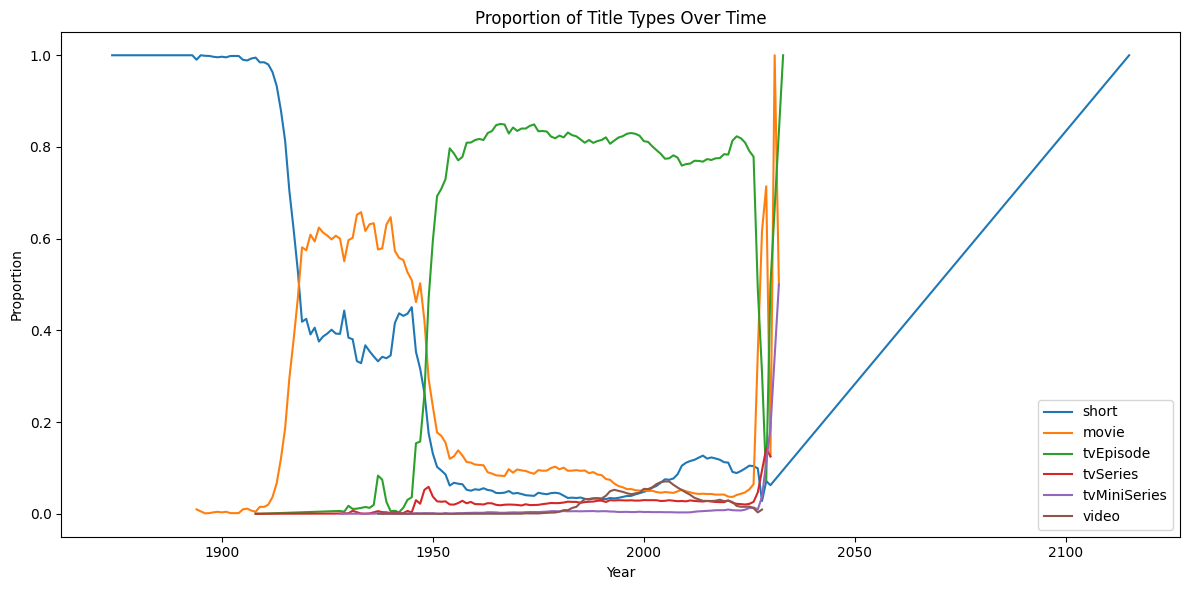

In [66]:
# Proportion of each title_type over time (aggregated, safe)
prop_sql = """
    SELECT start_year, title_type, COUNT(*) AS cnt
    FROM dim_title
    WHERE start_year IS NOT NULL
      AND title_type IN ('movie','tvSeries','tvMiniSeries','short','video','tvEpisode')
    GROUP BY start_year, title_type
    ORDER BY start_year, title_type
"""
df_prop = con.execute(prop_sql).df()

total_per_year = df_prop.groupby('start_year')['cnt'].transform('sum')
df_prop['proportion'] = df_prop['cnt'] / total_per_year

fig, ax = plt.subplots(figsize=(12,6))
for ttype in df_prop['title_type'].unique():
    subset = df_prop[df_prop['title_type'] == ttype]
    ax.plot(subset['start_year'], subset['proportion'], label=ttype)
ax.set_title('Proportion of Title Types Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plot_all['3.3_title_type_proportion'] = fig

#### Task 3.4: Industry Economics and Success Factors ####

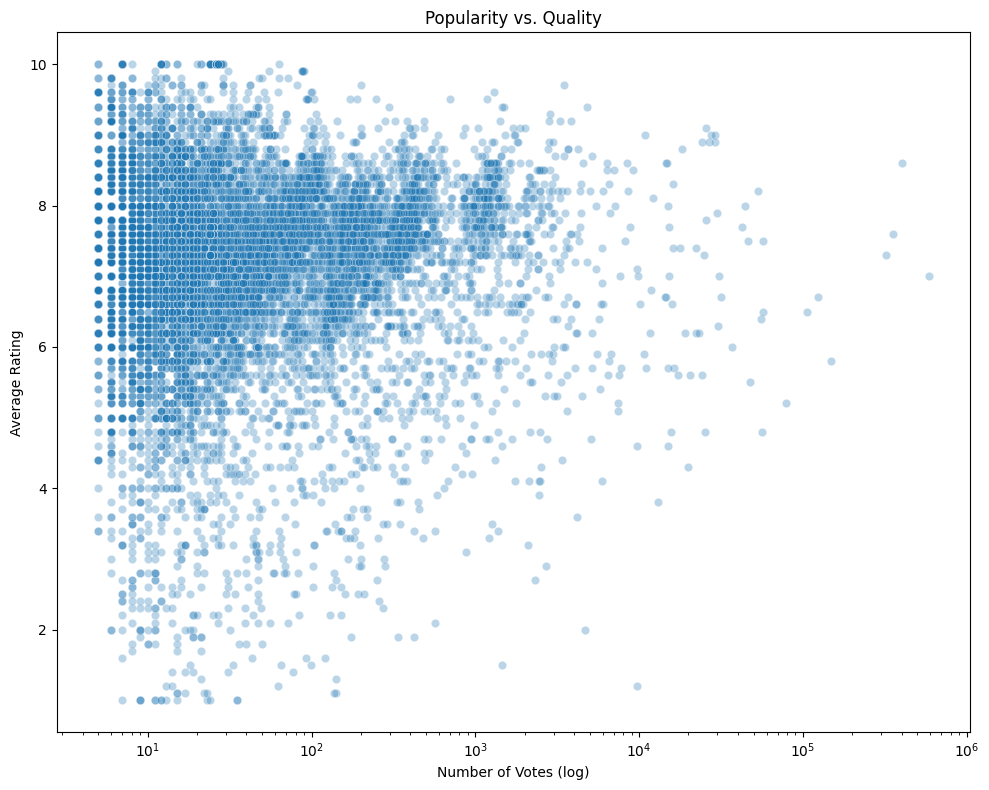

In [67]:
# Scatter: popularity vs quality (sampled)
pop_scatter_sql = """
    SELECT num_votes, average_rating
    FROM dim_title TABLESAMPLE SYSTEM (1 PERCENT) REPEATABLE(42)
    WHERE num_votes > 0 AND average_rating IS NOT NULL
    LIMIT 30000
"""
df_pop = con.execute(pop_scatter_sql).df()

fig, ax = plt.subplots(figsize=(10,8))
sns.scatterplot(data=df_pop, x='num_votes', y='average_rating', alpha=0.3, ax=ax)
ax.set_xscale('log')
ax.set_xlabel('Number of Votes (log)')
ax.set_ylabel('Average Rating')
ax.set_title('Popularity vs. Quality')
plt.tight_layout()
plot_all['3.4_pop_vs_quality'] = fig

In [68]:
# Quadrant chart (uses same sampled data, safe)
med_votes = df_pop['num_votes'].median()
med_rating = df_pop['average_rating'].median()

df_pop['quadrant'] = 'unknown'
df_pop.loc[(df_pop['num_votes'] > med_votes) & (df_pop['average_rating'] > med_rating), 'quadrant'] = 'Blockbuster Hits'
df_pop.loc[(df_pop['num_votes'] > med_votes) & (df_pop['average_rating'] <= med_rating), 'quadrant'] = 'Popular Duds'
df_pop.loc[(df_pop['num_votes'] <= med_votes) & (df_pop['average_rating'] > med_rating), 'quadrant'] = 'Hidden Gems'
df_pop.loc[(df_pop['num_votes'] <= med_votes) & (df_pop['average_rating'] <= med_rating), 'quadrant'] = 'Obscure Failures'

fig, ax = plt.subplots(figsize=(10,8))
colors = {'Blockbuster Hits':'green', 'Popular Duds':'red', 'Hidden Gems':'blue', 'Obscure Failures':'gray'}
for q in colors:
    subset = df_pop[df_pop['quadrant'] == q]
    ax.scatter(subset['num_votes'], subset['average_rating'], c=colors[q], label=q, alpha=0.5)
ax.axhline(med_rating, color='black', linestyle='--', alpha=0.5)
ax.axvline(med_votes, color='black', linestyle='--', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Number of Votes (log)')
ax.set_ylabel('Average Rating')
ax.set_title('Title Quadrants (median splits)')
ax.legend()
plt.tight_layout()
plot_all['3.4_quadrant_chart'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell102.png', dpi=150, bbox_inches='tight')
plt.close()


In [69]:
# Bar chart of most engaged titles (aggregated, safe)
top_votes_sql = """
    SELECT primary_title, num_votes
    FROM dim_title
    ORDER BY num_votes DESC
    LIMIT 20
"""
df_top_votes = con.execute(top_votes_sql).df()

fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=df_top_votes, x='num_votes', y='primary_title', hue='primary_title', palette='rocket', ax=ax)
ax.set_title('Top 20 Most Voted Titles')
ax.set_xlabel('Number of Votes')
ax.set_ylabel('Title')
plt.tight_layout()
plot_all['3.4_top_votes'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell103.png', dpi=150, bbox_inches='tight')
plt.close()


In [70]:
# Time series of average num_votes per year (aggregated, safe)
avg_votes_year_sql = """
    SELECT start_year, AVG(num_votes) AS avg_votes
    FROM dim_title
    WHERE start_year IS NOT NULL AND num_votes > 0
    GROUP BY start_year
    ORDER BY start_year
"""
df_avg_votes_year = con.execute(avg_votes_year_sql).df()

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data=df_avg_votes_year, x='start_year', y='avg_votes', ax=ax)
ax.set_title('Average Number of Votes per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Votes')
plt.tight_layout()
plot_all['3.4_avg_votes_time'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell104.png', dpi=150, bbox_inches='tight')
plt.close()


#### Task 3.5: Adult Content Analysis ####

In [71]:
# Count of adult vs non-adult titles (aggregated, safe)
adult_count_sql = """ 
    SELECT CASE WHEN CAST(is_adult AS INTEGER) = 1 THEN 'Adult' ELSE 'Non-Adult' END AS adult_status,
           COUNT(*) AS cnt
    FROM dim_title
    GROUP BY adult_status
"""
df_adult_cnt = con.execute(adult_count_sql).df()

fig, ax = plt.subplots(figsize=(6,6))
ax.bar(df_adult_cnt['adult_status'], df_adult_cnt['cnt'], color=['salmon','lightblue'])
ax.set_title('Adult vs. Non-Adult Titles')
ax.set_ylabel('Count')
plt.tight_layout()
plot_all['3.5_adult_counts'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell106.png', dpi=150, bbox_inches='tight')
plt.close()


In [72]:
# Box plot of rating by adult status (sampled)
adult_rating_sql = """
    SELECT CASE WHEN CAST(is_adult AS INTEGER) = 1 THEN 'Adult' ELSE 'Non-Adult' END AS adult_status,
           average_rating
    FROM dim_title TABLESAMPLE SYSTEM (1 PERCENT) REPEATABLE(42)
    WHERE average_rating IS NOT NULL
    LIMIT 20000
"""
df_adult_rating = con.execute(adult_rating_sql).df()

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=df_adult_rating, x='adult_status', y='average_rating', hue='adult_status', palette='Set3', ax=ax)
ax.set_title('Rating Distribution: Adult vs Non-Adult')
ax.set_xlabel('Content Type')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plot_all['3.5_adult_rating_box'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell107.png', dpi=150, bbox_inches='tight')
plt.close()


In [73]:
# Bar chart of genres associated with adult titles (aggregated, safe)
adult_genre_sql = """
    SELECT genre, COUNT(*) AS cnt
    FROM (
        SELECT unnest(string_split(genre_list, ',')) AS genre
        FROM dim_title
        WHERE CAST(is_adult AS INTEGER) = 1
          AND genre_list IS NOT NULL
    )
    GROUP BY genre
    ORDER BY cnt DESC
    LIMIT 15
"""
df_adult_genres = con.execute(adult_genre_sql).df()

fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=df_adult_genres, x='cnt', y='genre', hue='genre', palette='Reds_r', ax=ax)
ax.set_title('Most Common Genres in Adult Titles')
ax.set_xlabel('Title Count')
ax.set_ylabel('Genre')
plt.tight_layout()
plot_all['3.5_adult_genres'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell108.png', dpi=150, bbox_inches='tight')
plt.close()


In [74]:
# Time series of adult titles per year (aggregated, safe)
adult_year_sql = """
    SELECT start_year, COUNT(*) AS adult_count
    FROM dim_title
    WHERE CAST(is_adult AS INTEGER) = 1
      AND start_year IS NOT NULL
    GROUP BY start_year
    ORDER BY start_year
"""
df_adult_year = con.execute(adult_year_sql).df()

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df_adult_year, x='start_year', y='adult_count', ax=ax)
ax.set_title('Number of Adult Titles Released per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Title Count')
plt.tight_layout()
plot_all['3.5_adult_time_series'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell109.png', dpi=150, bbox_inches='tight')
plt.close()


In [75]:
# Weighted Rating Analysis (by vote count)
# Median votes = 26, so raw avg_rating is inflated by low-vote titles
# Apply Bayesian weighting: WR = (v*R + m*C) / (v + m)
# where R = avg rating, v = votes, C = global mean, m = median votes

import numpy as np
stats = con.execute("""
    SELECT
        AVG(average_rating) AS global_mean,
        MEDIAN(num_votes) AS median_votes,
        COUNT(*) AS total_rated
    FROM dim_title WHERE num_votes > 0 AND average_rating IS NOT NULL
""").fetchone()
C, m, total = stats
C = round(C, 2)
logger.info(f"Global mean rating (C): {C:.2f}")
logger.info(f"Median votes (m): {m:.0f}")
logger.info(f"Total rated titles: {total:,}")

# Compute correlation between votes and rating
corr = con.execute("""
    SELECT CORR(num_votes, average_rating)
    FROM dim_title WHERE num_votes > 0 AND average_rating IS NOT NULL
""").fetchone()[0]
logger.info(f"Correlation (votes vs rating): {corr:.3f}")

# Top 20 by weighted rating
logger.info(f"\nTop 20 by Bayesian Weighted Rating (m={m:.0f}):")
df_w = con.execute(f"""
    SELECT primary_title, start_year,
           ROUND(average_rating, 2) AS rating,
           num_votes AS votes,
           ROUND((CAST(num_votes AS DOUBLE) * CAST(average_rating AS DOUBLE) + {m} * {C}) / NULLIF(CAST(num_votes AS DOUBLE) + {m}, 0), 2) AS weighted_rating
    FROM dim_title
    WHERE num_votes > 0 AND average_rating IS NOT NULL
    ORDER BY weighted_rating DESC
    LIMIT 20
""").df()
for _, r in df_w.iterrows():
    logger.info(f"  {r['primary_title'][:60]:60s} ({r['start_year']}) raw={r['rating']} wgt={r['weighted_rating']} votes={int(r['votes']):,}")

# Rating by popularity segment
logger.info(f"\nRating by popularity segment:")
segments = con.execute("""
    SELECT CASE
        WHEN num_votes >= 100000 THEN 'high'
        WHEN num_votes >= 10000 THEN 'medium'
        WHEN num_votes > 0 THEN 'low'
        ELSE 'unrated'
    END AS segment,
    ROUND(AVG(average_rating), 2) AS avg_rating,
    ROUND(AVG(num_votes), 0) AS avg_votes,
    COUNT(*) AS cnt
    FROM dim_title WHERE average_rating IS NOT NULL
    GROUP BY segment
    ORDER BY MIN(CASE WHEN num_votes > 0 THEN num_votes ELSE 0 END) DESC
""").fetchall()
for seg, r, v, c in segments:
    logger.info(f"  {seg}: avg_rating={r}, avg_votes={int(v)}, count={c:,}")

# Scatter: raw vs weighted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_w['votes'], df_w['rating'], alpha=0.6, label='Raw Rating')
ax.scatter(df_w['votes'], df_w['weighted_rating'], alpha=0.6, label='Weighted Rating')
ax.set_xscale('log')
ax.set_xlabel('Number of Votes')
ax.set_ylabel('Rating')
ax.set_title('Raw vs Weighted Rating (Top 20 Weighted)')
ax.legend()
plt.tight_layout()
plot_all['weighted_rating_comparison'] = fig
plt.savefig(FIGURES_DIR / 'eda' / 'eda_cell110.png', dpi=150, bbox_inches='tight')
plt.close()


Global mean rating (C): 6.96
Median votes (m): 26
Total rated titles: 1,689,394
Correlation (votes vs rating): 0.010

Top 20 by Bayesian Weighted Rating (m=26):


  Grief 97% Stream 361                                         (2026) raw=10.0 wgt=9.94 votes=1,326
  Red Sea Film Fest 2024                                       (2025) raw=10.0 wgt=9.93 votes=1,072
  The View from Halfway Down                                   (2020) raw=9.9 wgt=9.9 votes=33,500
  Battle of the Bastards                                       (2016) raw=9.9 wgt=9.9 votes=309,581
  The Winds of Winter                                          (2016) raw=9.9 wgt=9.9 votes=228,444
  Re:Zero kara Hajimaru Isekai Seikatsu                        (2026) raw=9.9 wgt=9.9 votes=66,627
  Omae wa Dare da                                              (2026) raw=9.9 wgt=9.9 votes=46,006
  Ice Hockey: Courtney                                         (2008) raw=10.0 wgt=9.9 votes=731
  End of the Prologue                                          (2019) raw=9.9 wgt=9.9 votes=42,238
  Sozin's Comet, Part 4: Avatar Aang                           (2008) raw=9.9 wgt=9.9 votes=27,652
  I Thou

### Savestates ###

In [76]:
def save_figures(plot_dict: dict, folder: str = "figures", formats: list = None) -> None:
    """
    Save all Matplotlib/Plotly figures stored in a dictionary to image files.

    Parameters
    ----------
    plot_dict : dict
        Dictionary mapping figure keys (e.g., '1.1_genre_count') to figure objects.
    folder : str, optional
        Target directory (relative to project root) for saved images.
    formats : list of str, optional
        List of file formats to export, e.g. ['png', 'svg', 'pdf'].
        Defaults to ['png'].
    """
    if formats is None:
        formats = ["png"]

    root = Path.cwd().resolve().parent
    target_folder = FIGURES_DIR / 'eda'
    target_folder.mkdir(parents = True, exist_ok = True)

    for key, fig in plot_dict.items():
        # Sanitise filename: replace spaces / special characters
        safe_key = key.replace(" ", "_").replace("/", "_")
        for fmt in formats:
            # For Plotly figures, use write_image; for Matplotlib, use savefig
            if hasattr(fig, "write_image"):
                # Plotly figure
                path = target_folder / f"{safe_key}.{fmt}"
                fig.write_image(str(path))
            else:
                # Mathplotlib / Seaborn figure
                path = target_folder / f"{safe_key}.{fmt}"
                fig.savefig(str(path))
            logger.info(f"Figure saved: {safe_key}.{fmt} -> {path}")

In [77]:
save_figures(plot_all, formats = ["png"])

# Close DuckDB connection
con.close()
